# 스프린트 미션 4: Python EDA 실습

### 1\. 데이터 불러오기

제공된 '건강검진정보_2024.csv' 파일을 Pandas DataFrame으로 불러온 후, 상위 5개 로우를 출력하세요.  

---
*한글 파일이기 때문에 `encoding='cp949'`이라고 타입을 지정해 불러와야 합니다.

In [1]:
import platform
import matplotlib.pyplot as plt
import seaborn as sns

# OS에 따른 폰트 설정
os_name = platform.system()

if os_name == 'Windows': # 윈도우
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif os_name == 'Darwin': # 맥, macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else: # Linux (Colab 등)
    # Colab 환경에서만 apt-get이 작동하므로 예외 처리
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        pass

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font=plt.rcParams['font.family'], rc={"axes.unicode_minus": False})

In [2]:
# 필요한 라이브러리를 import한 후 데이터를 불러오는 코드를 입력하세요
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cjcode.my_utils import show_labels
from cjcode.my_utils import diff

health_df = pd.read_csv('건강검진정보_2024.csv', encoding='cp949')

미션 안내 문서에 정리되어 있는 데이터 설명을 참고해서 각 컬럼의 의미를 충분히 숙지한 후 다음 단계로 넘어가세요.  
필요하다면 상위 5개 외에 다른 로우들도 자유롭게 살펴보면서 데이터의 의미를 이해하는 시간을 가져보세요.

### 2\. Data Shape 확인

데이터가 몇 개의 컬럼과 로우로 이루어져있는지 확인합니다.

In [3]:
# Data Shape을 확인하는 코드를 입력하세요
health_df.shape

(1000000, 17)

### 3\. Data Type 확인
컬럼별 정보와 데이터 타입을 확인합니다.

In [4]:
# 컬럼별 정보와 데이터 타입을 확인하는 코드를 입력하세요
health_df.dtypes


기준년도         int64
가입자일련번호      int64
시도코드         int64
성별코드         int64
연령대코드        int64
신장           int64
체중           int64
허리둘레       float64
시력_좌       float64
시력_우       float64
청력_좌       float64
청력_우       float64
수축기혈압      float64
이완기혈압      float64
식전혈당       float64
흡연상태       float64
음주여부       float64
dtype: object

### 4\. 결측값 확인 및 처리
컬럼별 결측값(Null값)의 수를 확인하고, 해당 컬럼의 전체 데이터 중 결측값의 비중이 어느 정도인지도 계산해 보세요.   
이후 각 컬럼의 결측값을 어떻게 처리하면 좋을지 고민해서 적절히 처리해 보세요.

In [5]:
# 컬럼별 결측값 수를 확인하는 코드를 입력하세요
health_df.isna().sum()

기준년도          0
가입자일련번호       0
시도코드          0
성별코드          0
연령대코드         0
신장            0
체중            0
허리둘레        495
시력_좌        193
시력_우        192
청력_좌        148
청력_우        148
수축기혈압      5790
이완기혈압      5789
식전혈당       5847
흡연상태        118
음주여부         45
dtype: int64

In [6]:
# 컬럼별 결측값 비중을 확인하는 코드를 입력하세요
health_df.isna().mean()

기준년도       0.000000
가입자일련번호    0.000000
시도코드       0.000000
성별코드       0.000000
연령대코드      0.000000
신장         0.000000
체중         0.000000
허리둘레       0.000495
시력_좌       0.000193
시력_우       0.000192
청력_좌       0.000148
청력_우       0.000148
수축기혈압      0.005790
이완기혈압      0.005789
식전혈당       0.005847
흡연상태       0.000118
음주여부       0.000045
dtype: float64

In [7]:
# 컬럼별 결측값을 적절하게 처리하는 코드를 입력하세요
health_df = health_df.dropna()

### 5\. 중복값 확인 및 처리
중복된 데이터가 있는지도 확인하고 적절히 처리해 보세요.

In [8]:
health_df.head()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부
0,2024,4831755,41,2,13,160,50,70.0,1.0,1.0,1.0,1.0,107.0,77.0,70.0,1.0,1.0
1,2024,1154608,41,2,11,155,60,74.9,1.0,1.0,1.0,1.0,104.0,69.0,81.0,1.0,1.0
2,2024,3318236,41,2,13,150,55,74.0,1.0,1.0,1.0,1.0,134.0,83.0,106.0,1.0,1.0
3,2024,3770599,41,1,16,160,70,89.0,1.0,1.0,1.0,1.0,119.0,73.0,97.0,1.0,1.0
4,2024,2634185,41,1,11,175,65,76.0,1.0,1.0,1.0,1.0,103.0,64.0,115.0,1.0,1.0


In [9]:
# 데이터의 분포를 확인하는 코드를 입력하세요
health_df.duplicated().sum()

np.int64(0)

In [10]:
health_df.describe()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부
count,993215.0,9.932150e+05,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000,993215.000000
mean,2024.0,2.499613e+06,33.928804,1.481058,10.644872,162.784201,64.608030,81.549447,0.953954,0.951690,1.036181,1.034887,122.701553,75.230067,100.984602,1.537394,0.659607
std,0.0,1.443845e+06,12.509420,0.499641,3.052112,9.336620,14.026089,10.944535,0.569034,0.563613,0.198467,0.195078,14.593113,10.360325,22.996683,0.781136,0.473841
min,2024.0,9.000000e+00,11.000000,1.000000,5.000000,130.000000,30.000000,6.800000,0.100000,0.100000,1.000000,1.000000,60.000000,11.000000,17.000000,1.000000,0.000000
25%,2024.0,1.247471e+06,27.000000,1.000000,8.000000,155.000000,55.000000,74.000000,0.700000,0.700000,1.000000,1.000000,112.000000,68.000000,89.000000,1.000000,0.000000
50%,2024.0,2.499667e+06,41.000000,1.000000,11.000000,165.000000,65.000000,81.100000,0.900000,0.900000,1.000000,1.000000,121.000000,75.000000,96.000000,1.000000,1.000000
75%,2024.0,3.749694e+06,43.000000,2.000000,13.000000,170.000000,75.000000,88.500000,1.200000,1.200000,1.000000,1.000000,132.000000,81.000000,106.000000,2.000000,1.000000
max,2024.0,5.000000e+06,49.000000,2.000000,18.000000,195.000000,135.000000,999.000000,9.900000,9.900000,3.000000,3.000000,271.000000,182.000000,991.000000,3.000000,1.000000


In [11]:
health_df.duplicated(subset='가입자일련번호')

0         False
1         False
2         False
3         False
4         False
          ...  
999995    False
999996    False
999997    False
999998    False
999999    False
Length: 993215, dtype: bool

In [12]:
# 중복값을 점검하고 처리하는 코드를 입력하세요
health_df.drop_duplicates()

,기준년도,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부
0,2024,4831755,41,2,13,160,50,70.0,1.0,1.0,1.0,1.0,107.0,77.0,70.0,1.0,1.0
1,2024,1154608,41,2,11,155,60,74.9,1.0,1.0,1.0,1.0,104.0,69.0,81.0,1.0,1.0
2,2024,3318236,41,2,13,150,55,74.0,1.0,1.0,1.0,1.0,134.0,83.0,106.0,1.0,1.0
3,2024,3770599,41,1,16,160,70,89.0,1.0,1.0,1.0,1.0,119.0,73.0,97.0,1.0,1.0
4,2024,2634185,41,1,11,175,65,76.0,1.0,1.0,1.0,1.0,103.0,64.0,115.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2024,1945007,27,2,17,150,45,76.2,0.4,0.3,1.0,1.0,125.0,90.0,196.0,1.0,0.0
999996,2024,2558884,28,1,12,160,70,86.1,0.7,0.7,1.0,1.0,132.0,97.0,91.0,1.0,0.0
999997,2024,4441437,41,1,12,160,65,78.5,0.9,0.9,1.0,1.0,102.0,69.0,99.0,3.0,0.0
999998,2024,4313591,30,1,8,175,95,105.0,1.5,1.5,1.0,1.0,164.0,110.0,116.0,1.0,0.0


### 6\. 이상치 확인 및 처리
컬럼별 데이터의 분포를 확인한 후 이상치로 의심되는 값이 있는지 점검합니다. 이상치로 판단되는 수치가 있다면 적절히 처리해 보세요.

In [104]:
health_df.describe()

,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,BMI,시력차이
count,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000
mean,162.747171,63.955600,80.803726,0.958405,0.956340,1.029773,1.028656,121.612622,74.626232,96.722236,23.957003,0.205794
std,9.291802,13.346247,10.263722,0.545101,0.542686,0.169959,0.166837,13.484925,9.603998,11.662398,3.736498,0.590411
min,130.000000,30.000000,52.300000,0.100000,0.100000,1.000000,1.000000,82.000000,49.000000,64.000000,11.000000,0.000000
25%,155.000000,55.000000,73.000000,0.700000,0.700000,1.000000,1.000000,112.000000,68.000000,89.000000,21.000000,0.000000
50%,165.000000,65.000000,81.000000,1.000000,1.000000,1.000000,1.000000,120.000000,75.000000,96.000000,24.000000,0.100000
75%,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,81.000000,103.000000,26.000000,0.300000
max,195.000000,135.000000,110.200000,9.900000,9.900000,2.000000,2.000000,162.000000,100.000000,131.000000,53.000000,9.800000


In [105]:
# 이상치를 점검하고 처리하는 코드를 입력하세요
health_df.sort_values(by='허리둘레', ascending=False)

,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부,BMI,비만도,시력차이
567305,823084,서울특별시,남,50~54세,175,105,110.2,0.7,1.5,2.0,1.0,122.0,86.0,122.0,smoking,drinking,34.0,비만,0.8
463577,3809137,충청북도,여,55~59세,160,90,110.2,0.6,0.9,1.0,1.0,160.0,93.0,94.0,not,not,35.0,비만,0.3
474833,4577173,세종특별자치시,남,50~54세,175,95,110.2,1.2,1.2,1.0,1.0,128.0,82.0,77.0,smoked,drinking,31.0,비만,0.0
380,4101817,경기도,남,35~39세,165,95,110.2,1.0,1.0,1.0,1.0,122.0,72.0,122.0,not,not,35.0,비만,0.0
654741,3268158,경기도,남,40~44세,175,105,110.2,1.2,1.2,1.0,1.0,120.0,74.0,114.0,smoked,drinking,34.0,비만,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6383,4109321,경기도,여,35~39세,150,35,52.5,1.0,0.9,1.0,1.0,128.0,89.0,104.0,not,drinking,16.0,저체중,0.1
434931,2636415,경상북도,여,30~34세,145,40,52.5,0.1,0.5,1.0,1.0,115.0,78.0,78.0,not,drinking,19.0,정상체중,0.4
815820,4287659,경상남도,여,55~59세,145,30,52.5,1.2,1.0,1.0,1.0,101.0,58.0,86.0,not,not,14.0,저체중,0.2
147750,3522232,대전광역시,여,30~34세,160,35,52.4,1.5,1.5,1.0,1.0,116.0,72.0,80.0,not,drinking,14.0,저체중,0.0


In [106]:
q1 = health_df['허리둘레'].quantile(0.25)
q3 = health_df['허리둘레'].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr
con1 = health_df['허리둘레'] >= lower_limit
con2 = health_df['허리둘레'] <= upper_limit
health_df = health_df[con1 & con2]



In [107]:
health_df.sort_values(by='허리둘레', ascending=False)

,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부,BMI,비만도,시력차이
567305,823084,서울특별시,남,50~54세,175,105,110.2,0.7,1.5,2.0,1.0,122.0,86.0,122.0,smoking,drinking,34.0,비만,0.8
463577,3809137,충청북도,여,55~59세,160,90,110.2,0.6,0.9,1.0,1.0,160.0,93.0,94.0,not,not,35.0,비만,0.3
474833,4577173,세종특별자치시,남,50~54세,175,95,110.2,1.2,1.2,1.0,1.0,128.0,82.0,77.0,smoked,drinking,31.0,비만,0.0
380,4101817,경기도,남,35~39세,165,95,110.2,1.0,1.0,1.0,1.0,122.0,72.0,122.0,not,not,35.0,비만,0.0
654741,3268158,경기도,남,40~44세,175,105,110.2,1.2,1.2,1.0,1.0,120.0,74.0,114.0,smoked,drinking,34.0,비만,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6383,4109321,경기도,여,35~39세,150,35,52.5,1.0,0.9,1.0,1.0,128.0,89.0,104.0,not,drinking,16.0,저체중,0.1
434931,2636415,경상북도,여,30~34세,145,40,52.5,0.1,0.5,1.0,1.0,115.0,78.0,78.0,not,drinking,19.0,정상체중,0.4
815820,4287659,경상남도,여,55~59세,145,30,52.5,1.2,1.0,1.0,1.0,101.0,58.0,86.0,not,not,14.0,저체중,0.2
147750,3522232,대전광역시,여,30~34세,160,35,52.4,1.5,1.5,1.0,1.0,116.0,72.0,80.0,not,drinking,14.0,저체중,0.0


In [108]:
q1 = health_df['수축기혈압'].quantile(0.25)
q3 = health_df['수축기혈압'].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr
con1 = health_df['수축기혈압'] >= lower_limit
con2 = health_df['수축기혈압'] <= upper_limit
health_df = health_df[con1 & con2]

In [109]:
q1 = health_df['이완기혈압'].quantile(0.25)
q3 = health_df['이완기혈압'].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr
con1 = health_df['이완기혈압'] >= lower_limit
con2 = health_df['이완기혈압'] <= upper_limit
health_df = health_df[con1 & con2]

In [110]:
q1 = health_df['식전혈당'].quantile(0.25)
q3 = health_df['식전혈당'].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr
con1 = health_df['식전혈당'] >= lower_limit
con2 = health_df['식전혈당'] <= upper_limit
health_df = health_df[con1 & con2]

In [111]:
con_left = (health_df['청력_좌'] == 1) | (health_df['청력_좌'] == 2)
con_right = (health_df['청력_우'] == 1) | (health_df['청력_우'] == 2)
health_df = health_df[con_left & con_right]

In [112]:
health_df.describe()

,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,BMI,시력차이
count,870716.000000,870716.000000,870716.000000,870716.000000,870716.000000,870716.000000,870716.000000,870716.000000,870716.000000,870716.000000,870716.000000,870716.000000
mean,162.766671,63.830112,80.619119,0.960173,0.958006,1.028980,1.027814,121.144266,74.358046,96.019784,23.904251,0.204611
std,9.280923,13.303861,10.232869,0.539828,0.537247,0.167749,0.164439,13.059442,9.350162,10.689282,3.717326,0.581395
min,130.000000,30.000000,52.300000,0.100000,0.100000,1.000000,1.000000,85.000000,50.000000,68.000000,11.000000,0.000000
25%,155.000000,55.000000,73.000000,0.700000,0.700000,1.000000,1.000000,112.000000,68.000000,89.000000,21.000000,0.000000
50%,165.000000,60.000000,80.500000,1.000000,1.000000,1.000000,1.000000,120.000000,74.000000,95.000000,24.000000,0.100000
75%,170.000000,70.000000,87.900000,1.200000,1.200000,1.000000,1.000000,130.000000,80.000000,103.000000,26.000000,0.300000
max,195.000000,135.000000,110.200000,9.900000,9.900000,2.000000,2.000000,157.000000,98.000000,124.000000,50.000000,9.800000


### 7\. 시도코드 & 연령대코드 정리
현재 이 데이터에는 `시도코드`와 `연령대코드` 컬럼이 숫자로 된 코드로 적혀 있어 알아보기가 어렵습니다.   
보다 직관적으로 분석할 수 있도록 두 컬럼의 코드를 실제 의미를 담은 문자열로 변경해 보세요.
- `시도코드`: 11 → "서울특별시", 26 → "부산광역시", ... 이런 식으로 치환
- `연령대코드`: 1 → "0-4", 2 → "5-9", ... 이런 식으로 치환

In [23]:
# '시도코드' 컬럼을 변환하는 코드를 입력하세요
health_df['시도코드'] = health_df['시도코드'].astype('string')

num_list = [11, 26, 27, 28, 29, 30, 31, 36, 41, 42, 43, 44, 45, 46, 47, 48, 49]
name_list = ['서울특별시', '부산광역시', '대구광역시', '인천광역시', '광주광역시', '대전광역시', '울산광역시', '세종특별자치시',
            '경기도','강원도', '충청북도', '충청남도', '전라북도', '전라남도', '경상북도', '경상남도', '제주특별자치도']
for key,values in zip(num_list, name_list):
    health_df.loc[health_df['시도코드'] == str(key), '시도코드'] = values 


health_df[['시도코드']]    


,시도코드
0,경기도
1,경기도
2,경기도
3,경기도
4,경기도
...,...
999992,대구광역시
999994,경기도
999996,인천광역시
999997,경기도


In [24]:
# '연령대코드' 컬럼을 변환하는 코드를 입력하세요
health_df['연령대코드'] = health_df['연령대코드'].astype('string')

n_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
age_list = ['0~4세', '5~9세', '10~14세', '15~19세', '20~24세', '25~29세', '30~34세', '35~39세', '40~44세',
         '45~49세', '50~54세', '55~59세', '60~64세', '65~69세', '70~74세', '75~79세', '80~84세', '85세+']      		



for key,values in zip(n_list, age_list):
    health_df.loc[health_df['연령대코드'] == str(key), '연령대코드'] = values


health_df[['연령대코드']]    

,연령대코드
0,60~64세
1,50~54세
2,60~64세
3,75~79세
4,50~54세
...,...
999992,60~64세
999994,60~64세
999996,55~59세
999997,55~59세


In [25]:
health_df['성별코드'] = health_df['성별코드'].astype('string')
s_list = [1, 2]
sex_list = ['남', '여']


for key,values in zip(s_list, sex_list):
    health_df.loc[health_df['성별코드'] == str(key), '성별코드'] = values


health_df['성별코드']





0         여
1         여
2         여
3         남
4         남
         ..
999992    여
999994    남
999996    남
999997    남
999999    남
Name: 성별코드, Length: 904323, dtype: string

In [26]:
health_df['흡연상태'] = health_df['흡연상태'].astype('string')
smoking_n_list = [1, 2, 3]
smoke_list = ['not', 'smoked', 'smoking']


for key,values in zip(smoking_n_list, smoke_list):
    health_df.loc[health_df['흡연상태'] == str(float(key)), '흡연상태'] = values


health_df['흡연상태']

0             not
1             not
2             not
3             not
4             not
           ...   
999992        not
999994    smoking
999996        not
999997    smoking
999999     smoked
Name: 흡연상태, Length: 904323, dtype: string

In [27]:
health_df['음주여부'] = health_df['음주여부'].astype('string')
smoking_n_list = [0, 1]
smoke_list = ['not', 'drinking']


for key,values in zip(smoking_n_list, smoke_list):
    health_df.loc[health_df['음주여부'] == str(float(key)), '음주여부'] = values


health_df['음주여부']

0         drinking
1         drinking
2         drinking
3         drinking
4         drinking
            ...   
999992         not
999994         not
999996         not
999997         not
999999         not
Name: 음주여부, Length: 904323, dtype: string

In [28]:
health_df['신장'].sort_values().tail(10)

369275    195
787879    195
30625     195
526842    195
750735    195
793600    195
620006    195
940759    195
910974    195
899088    195
Name: 신장, dtype: int64

### 8\. 수치형 변수와 범주형 변수의 기술통계량 확인
컬럼을 수치형 변수와 범주형 변수로 구분한 후, 각각의 주요 기술통계량을 확인해 보세요. 수치형 변수와 범주형 변수에서 살펴볼 수 있는 기술통계량에는 차이가 있습니다.

---
*값이 숫자로 기록되어 있어도 수치형 변수라고 보기 어려운 경우들도 있으니 유의해 주세요. (예: `흡연상태`)

In [29]:
# 수치형 변수만 필터링한 후, 주요 기술통계량을 살펴보세요
numeric_col = health_df.select_dtypes(include='number').columns.to_list()


In [30]:
# 범주형 변수만 필터링한 후, 주요 기술통계량을 살펴보세요
object_col = health_df.select_dtypes(include='string').columns.to_list()

### 9\. 주요 수치형 변수의 분포 시각화
박스 플롯, 히스토그램 등으로 주요 수치형 변수(신장, 체중, 허리둘레, 수축기혈압)의 분포를 살펴보세요. 성별에 따라 구분해서도 살펴보면 좋습니다.

In [31]:
health_df['연령대코드'] = pd.Categorical(health_df['연령대코드'], ordered=True, categories=['0~4세', '5~9세', '10~14세', '15~19세', '20~24세', '25~29세', '30~34세', '35~39세', '40~44세',
         '45~49세', '50~54세', '55~59세', '60~64세', '65~69세', '70~74세', '75~79세', '80~84세', '85세+'])

In [32]:
health_df['기준년도'].unique()

array([2024])

In [33]:
health_df = health_df.drop(columns=['기준년도'])

In [34]:
health_df['가입자일련번호'] = health_df['가입자일련번호'].astype('str')

In [35]:
numeric_col = health_df.select_dtypes(include='number').columns.to_list()

In [36]:
object_col = health_df.select_dtypes(include='string').columns.to_list()

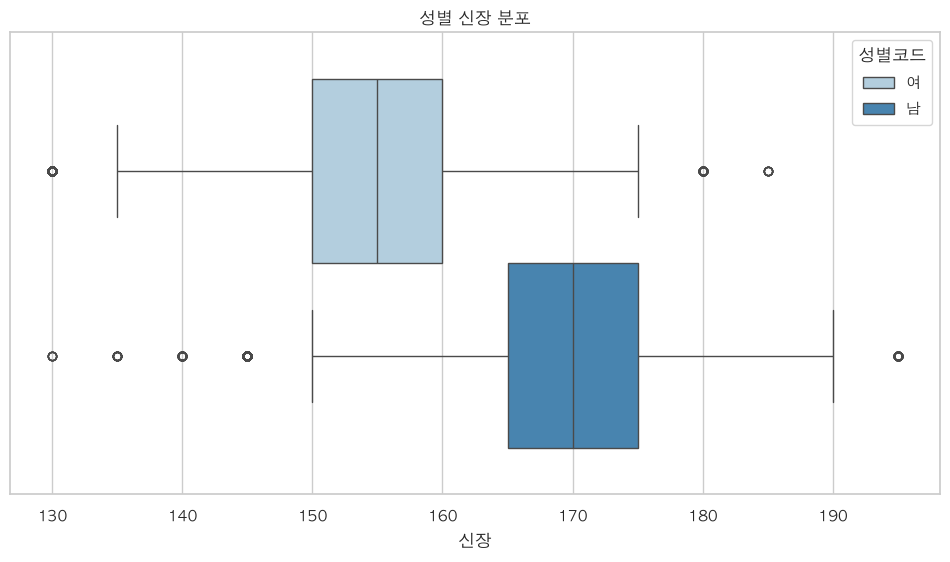

In [37]:
# 신장의 분포를 성별 기준으로 구분해 살펴보세요
plt.figure(figsize=(12, 6))
sns.boxplot(data=health_df, x='신장', hue='성별코드' , palette='Blues')
plt.title('성별 신장 분포')


plt.show()

/var/folders/r9/mb6dyn9n1qz5jbc54l10jv240000gn/T/ipykernel_2555/3490628060.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(data=health_df, x='체중' , palette='Blues', bw_method=0.5, fill=True)


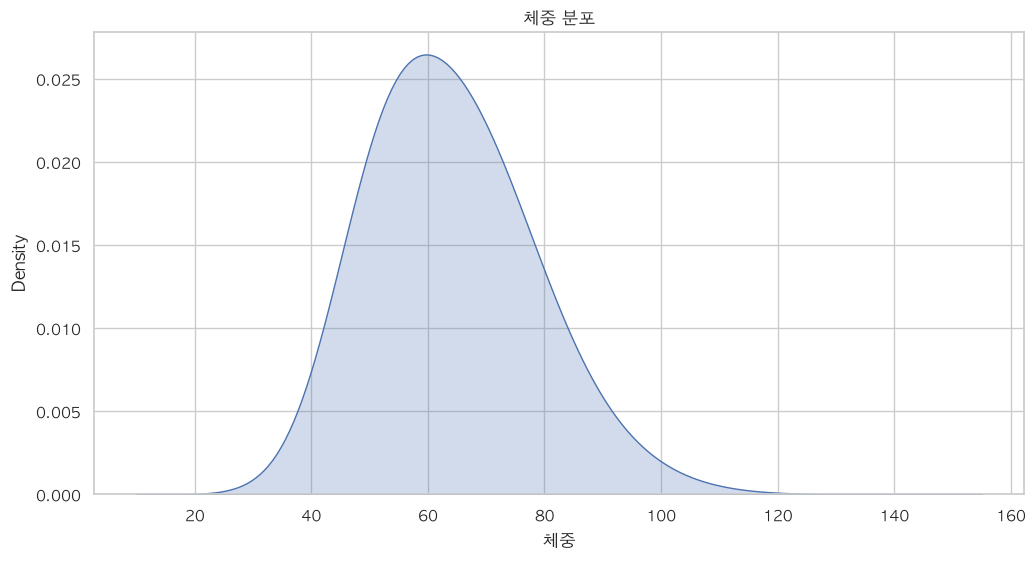

In [38]:
# 체중의 분포를 시각화해 살펴보세요
plt.figure(figsize=(12, 6))
sns.kdeplot(data=health_df, x='체중' , palette='Blues', bw_method=0.5, fill=True)
plt.title('체중 분포')


plt.show()

In [39]:
# 체중의 분포를 성별 기준으로 구분해 살펴보세요
weight_df = health_df.groupby(['체중', '성별코드'])['가입자일련번호'].agg('count').reset_index()
weight_df

,체중,성별코드,가입자일련번호
0,30,남,11
1,30,여,254
2,35,남,99
3,35,여,2315
4,40,남,717
5,40,여,16279
6,45,남,3502
7,45,여,56322
8,50,남,11780
9,50,여,101880


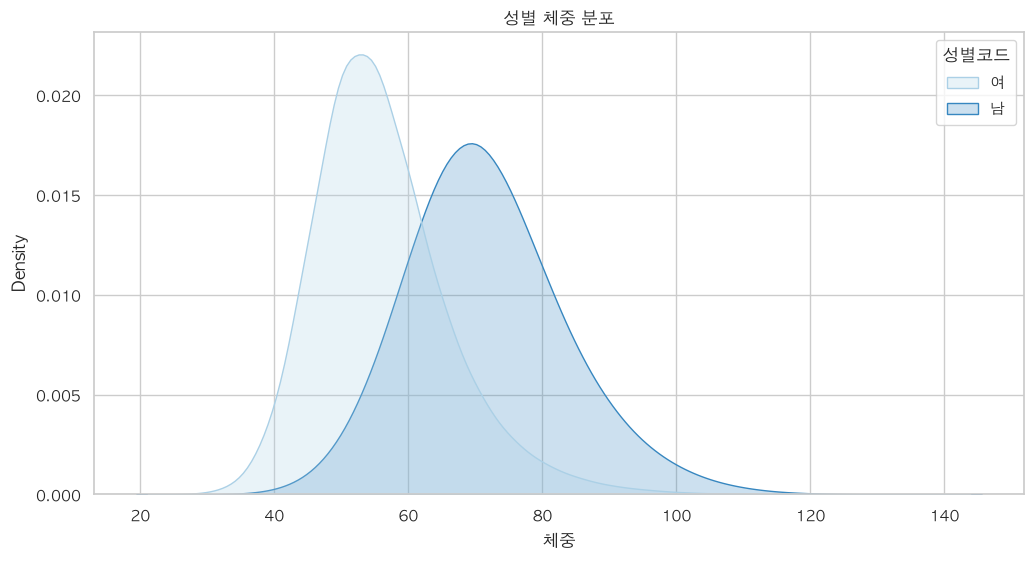

In [40]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=health_df, x='체중', hue='성별코드' , palette='Blues', bw_method=0.3, fill=True)
plt.title('성별 체중 분포')


plt.show()

/var/folders/r9/mb6dyn9n1qz5jbc54l10jv240000gn/T/ipykernel_2555/1349048236.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=health_df, x='허리둘레',   palette='Blues')


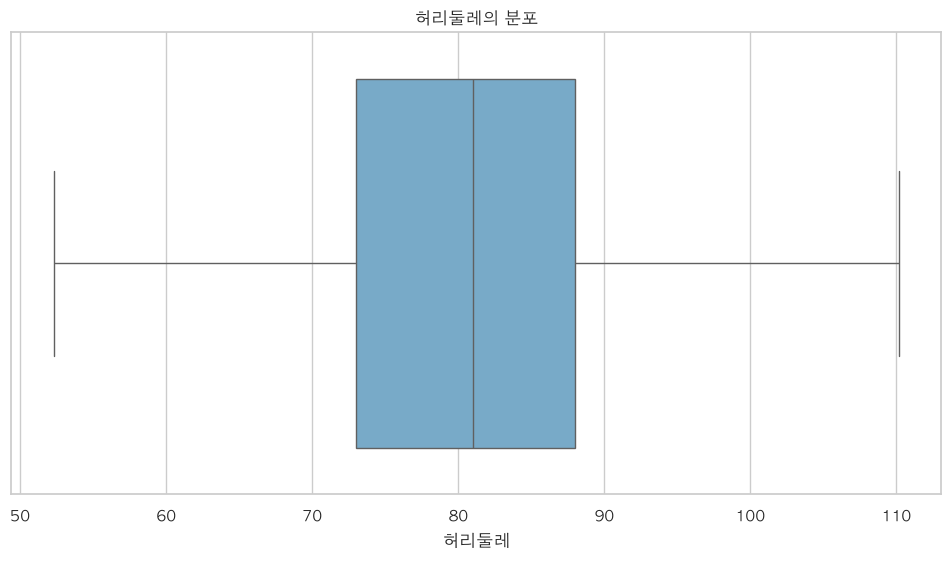

In [41]:
# 허리둘레의 분포를 시각화해 살펴보세요
plt.figure(figsize=(12, 6))
sns.boxplot(data=health_df, x='허리둘레',   palette='Blues')
plt.title('허리둘레의 분포')


plt.show()

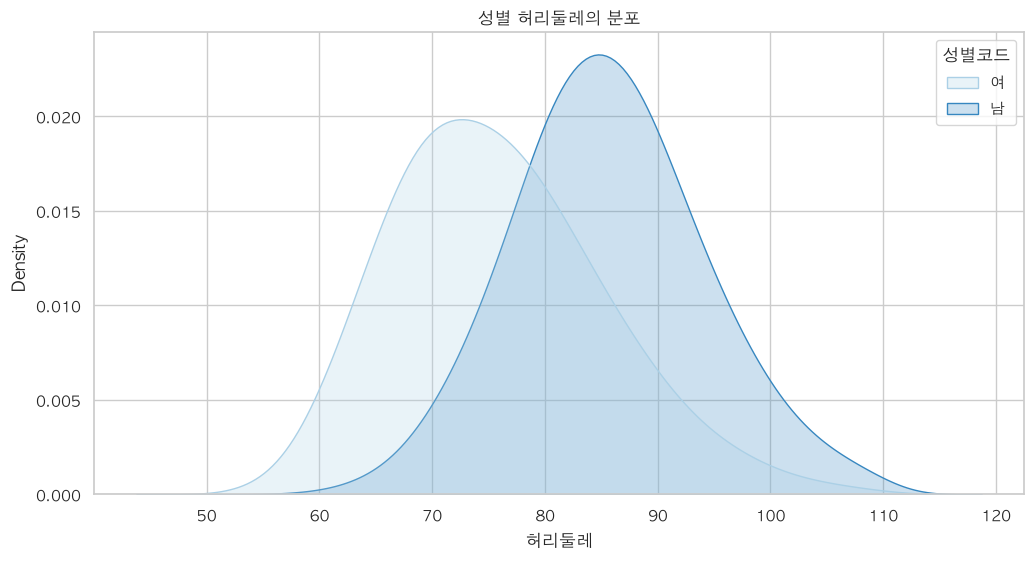

In [42]:
# 허리둘레의 분포를 성별 기준으로 구분해 살펴보세요
plt.figure(figsize=(12, 6))
sns.kdeplot(data=health_df, x='허리둘레', hue='성별코드' , palette='Blues', bw_method=0.3, fill=True)
plt.title('성별 허리둘레의 분포')


plt.show()

/var/folders/r9/mb6dyn9n1qz5jbc54l10jv240000gn/T/ipykernel_2555/602364995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=health_df, x='수축기혈압',   palette='Blues')


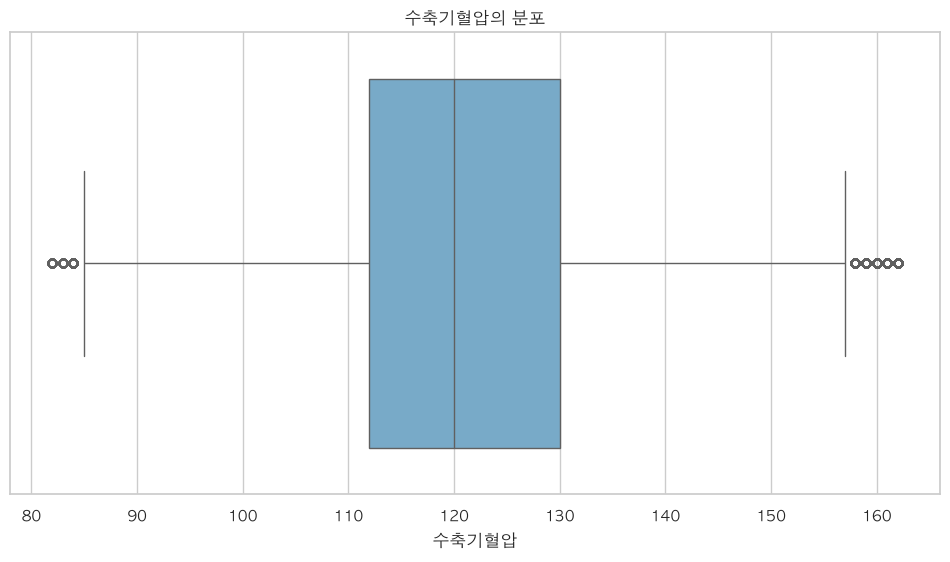

In [43]:
# 수축기혈압의 분포를 시각화해 살펴보세요
plt.figure(figsize=(12, 6))
sns.boxplot(data=health_df, x='수축기혈압',   palette='Blues')
plt.title('수축기혈압의 분포')


plt.show()

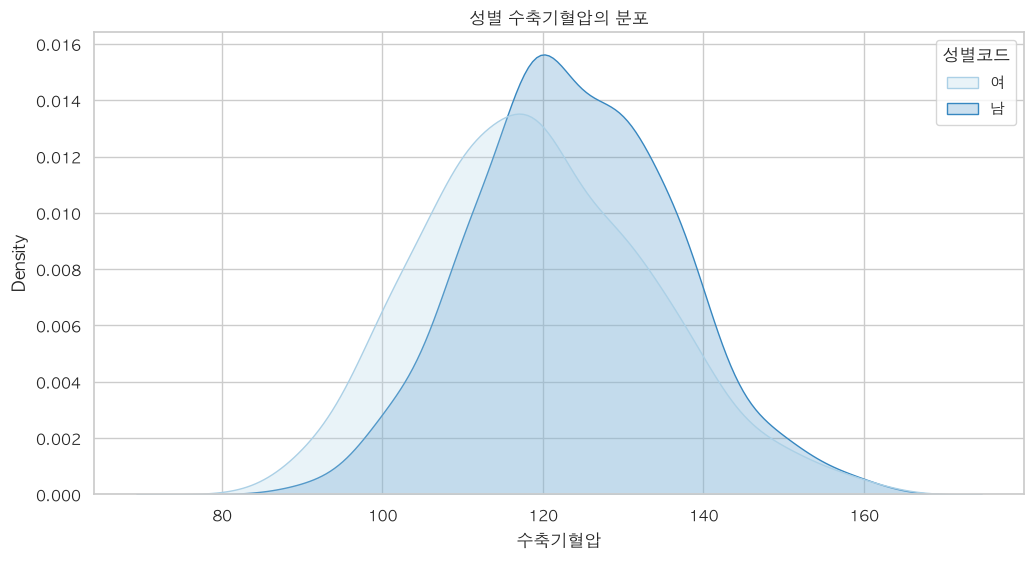

In [44]:
# 수축기혈압의 분포를 성별 기준으로 구분해 살펴보세요
plt.figure(figsize=(12, 6))
sns.kdeplot(data=health_df, x='수축기혈압', hue='성별코드' , palette='Blues', bw_method=0.3, fill=True)
plt.title('성별 수축기혈압의 분포')


plt.show()

### 10\. 주요 수치형 변수 간 관계 분석
주요 수치형 변수(신장, 체중, 허리둘레, 수축기혈압) 간의 상관관계를 확인해 보세요.  
먼저 Pairplot으로 변수 간 관계를 시각화해 확인한 후, 변수 간 상관계수를 계산하고 히트맵으로 나타내보세요.

In [45]:
# Pairplot으로 변수 간 관계를 시각화하세요

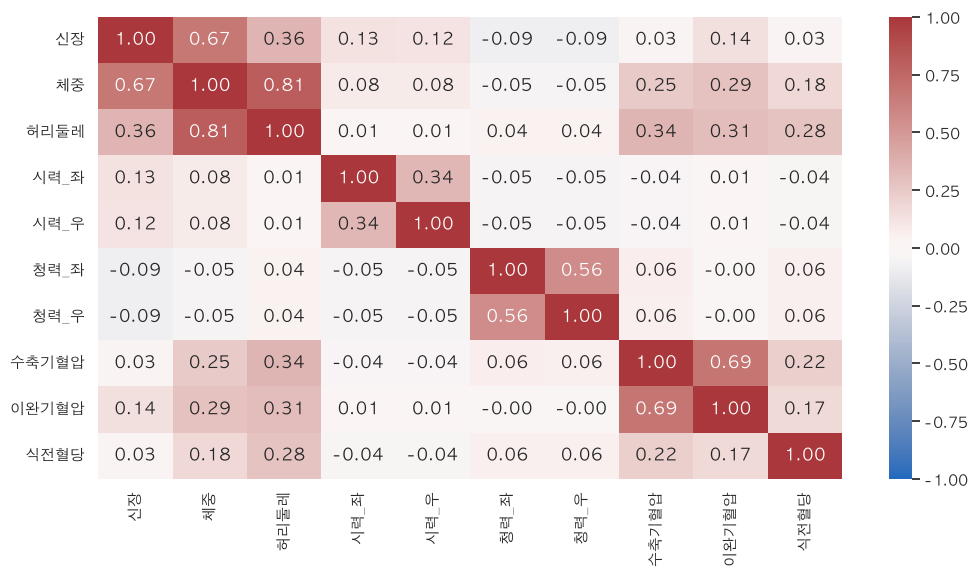

In [46]:
# 변수 간 상관계수를 계산하고 히트맵으로 나타내세요
plt.figure(figsize=(12,6))
con1 = health_df[numeric_col].corr()
sns.heatmap(con1, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.show()

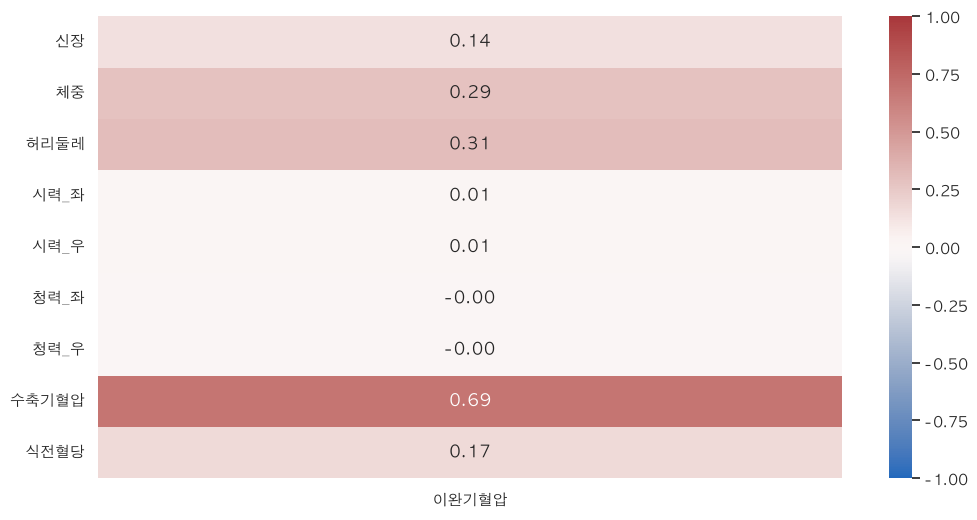

In [47]:
plt.figure(figsize=(12,6))
con1 = health_df[numeric_col].corr()[['이완기혈압']].drop('이완기혈압', axis=0)
sns.heatmap(con1, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.show()

### 11\. 연령대별 주요 건강 지표 분석
연령대별로 주요 건강 지표(신장, 체중, 허리둘레, 수축기혈압)이 어떻게 달라지는지 확인해 보세요.  
연령대별 평균값을 집계한 후, 연령 증가에 따라 각 지표가 어떻게 변하는지 시각화해 살펴보면 됩니다.

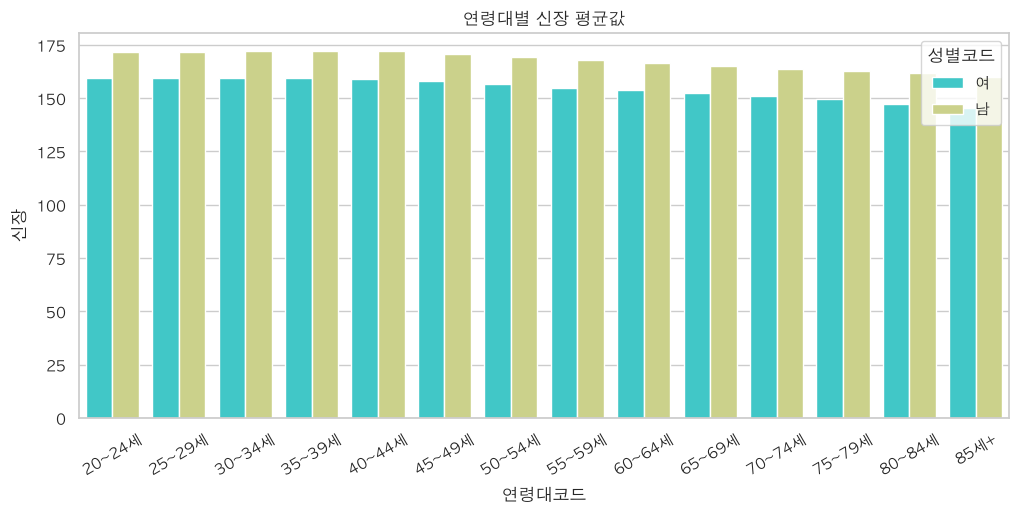

In [48]:
# 연령대별 신장 평균값을 비교해 보세요
plt.figure(figsize=(12,5))
h_label = ['20~24세', '25~29세', '30~34세', '35~39세', '40~44세',
         '45~49세', '50~54세', '55~59세', '60~64세', '65~69세', '70~74세', '75~79세', '80~84세', '85세+']
sns.barplot(data=health_df, x='연령대코드', y='신장', estimator='mean', hue='성별코드', palette='rainbow', order=h_label, errorbar=None)
plt.xticks(rotation=30)
plt.title('연령대별 신장 평균값')

plt.show()

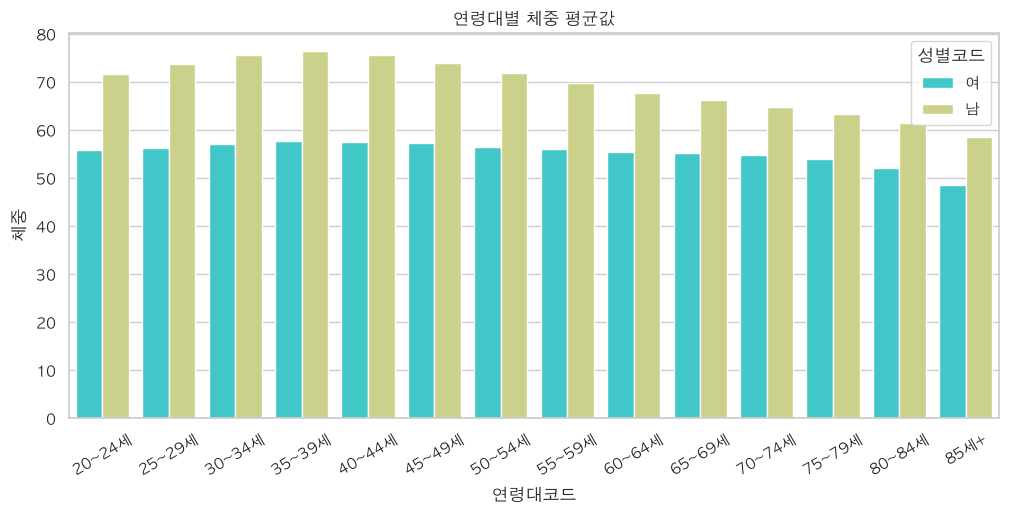

In [49]:
# 연령대별 체중 평균값을 비교해 보세요
plt.figure(figsize=(12,5))

sns.barplot(data=health_df, x='연령대코드', y='체중', estimator='mean', hue='성별코드', palette='rainbow', order=h_label, errorbar=None)
plt.xticks(rotation=30)
plt.title('연령대별 체중 평균값')

plt.show()

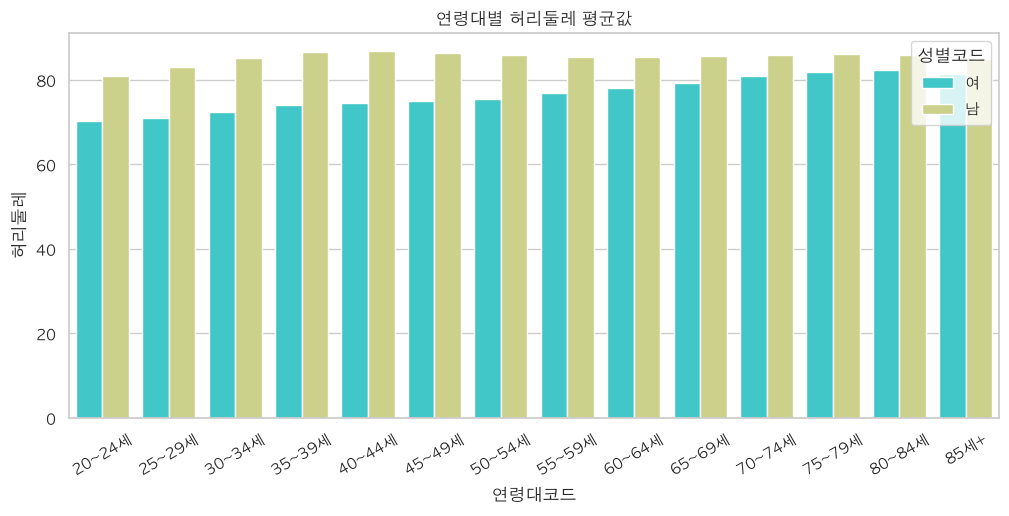

In [50]:
# 연령대별 허리둘레 평균값을 비교해 보세요
plt.figure(figsize=(12,5))
h_label = ['20~24세', '25~29세', '30~34세', '35~39세', '40~44세',
         '45~49세', '50~54세', '55~59세', '60~64세', '65~69세', '70~74세', '75~79세', '80~84세', '85세+']
sns.barplot(data=health_df, x='연령대코드', y='허리둘레', estimator='mean', hue='성별코드', palette='rainbow', order=h_label, errorbar=None)
plt.xticks(rotation=30)
plt.title('연령대별 허리둘레 평균값')

plt.show()

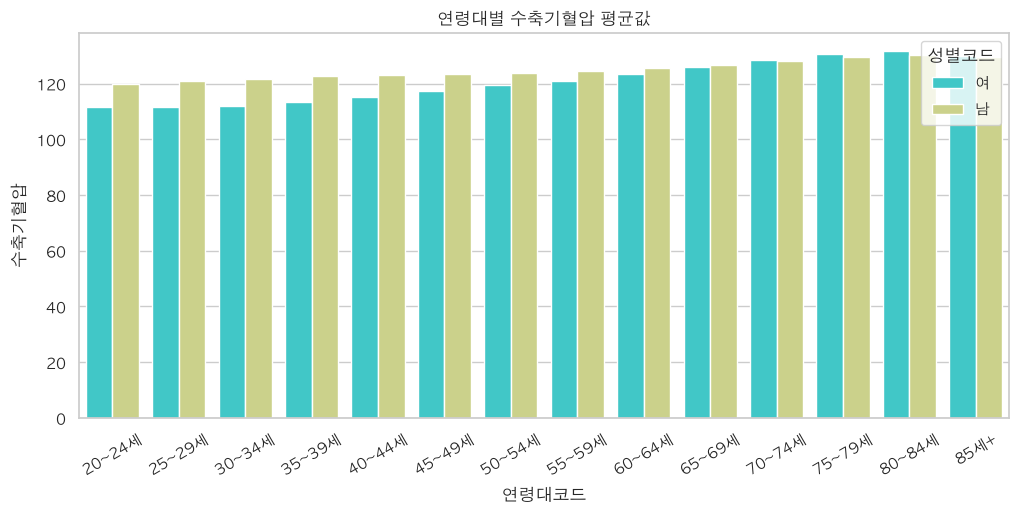

In [51]:
# 연령대별 수축기혈압 평균값을 비교해 보세요
plt.figure(figsize=(12,5))
age_label = ['20~24세', '25~29세', '30~34세', '35~39세', '40~44세',
         '45~49세', '50~54세', '55~59세', '60~64세', '65~69세', '70~74세', '75~79세', '80~84세', '85세+']
sns.barplot(data=health_df, x='연령대코드', y='수축기혈압', estimator='mean', hue='성별코드', palette='rainbow', order=age_label, errorbar=None)
plt.xticks(rotation=30)
plt.title('연령대별 수축기혈압 평균값')

plt.show()

### 12\. 성별에 따른 흡연 및 음주 상태 비교

성별에 따라 흡연 및 음주 상태에 차이가 있는지 비교해 보세요. 수치로만 비교하는 걸 넘어 시각화까지 해서 살펴보면 더 좋습니다.

In [52]:
health_df['흡연상태'].unique()

<StringArray>
['not', 'smoked', 'smoking']
Length: 3, dtype: string

In [53]:
# 성별에 따른 흡연 상태를 비교해 보세요
smoke_df = health_df.groupby(['성별코드', '흡연상태'], as_index=False)['가입자일련번호'].count()


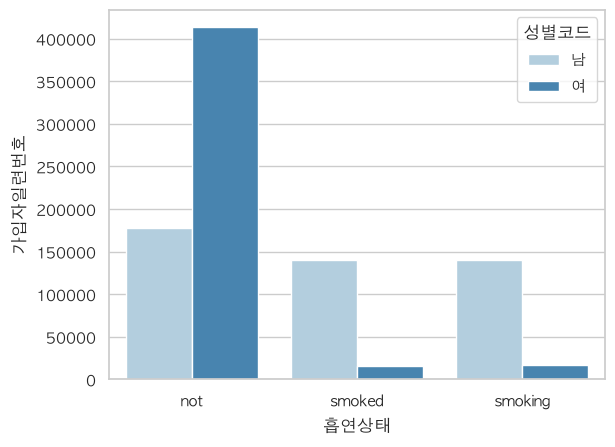

In [54]:
sns.barplot(data=smoke_df, x='흡연상태', y='가입자일련번호', hue='성별코드', palette='Blues', errorbar=None)
plt.show()

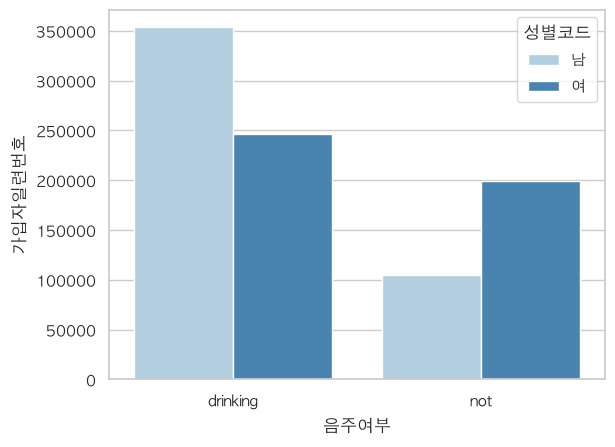

In [55]:
# 성별에 따른 음주 상태를 비교해 보세요
drink_df = health_df.groupby(['성별코드', '음주여부'], as_index=False)['가입자일련번호'].count()
sns.barplot(data=drink_df, x='음주여부', y='가입자일련번호', hue='성별코드', palette='Blues', errorbar=None)
plt.show()

### 13\. BMI 계산

BMI(체질량 지수)는 개인의 체중(kg)을 신장(m)의 제곱으로 나눈 값으로 계산하며, 비만도를 판단하는 데 널리 사용됩니다. BMI를 계산한 후 아래 기준에 따라 비만도를 판단해 보세요.  
BMI와 비만도 정보는 각각 새로운 컬럼을 생성해 저장합니다.

$$BMI= \frac{체중(kg)}{신장(m)^2}$$

BMI에 따른 비만도 판단 기준:

- 저체중: BMI < 18.5
- 정상 체중: 18.5 ≤ BMI < 25
- 과체중: 25 ≤ BMI < 30
- 비만: BMI ≥ 30

In [56]:
health_df['신장'].head()

0    160
1    155
2    150
3    160
4    175
Name: 신장, dtype: int64

In [57]:
# 'BMI' 컬럼을 새로 생성하세요
health_df['BMI'] = round(health_df['체중'] / (health_df['신장'] / 100) ** 2, 0)
health_df.head()


,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부,BMI
0,4831755,경기도,여,60~64세,160,50,70.0,1.0,1.0,1.0,1.0,107.0,77.0,70.0,not,drinking,20.0
1,1154608,경기도,여,50~54세,155,60,74.9,1.0,1.0,1.0,1.0,104.0,69.0,81.0,not,drinking,25.0
2,3318236,경기도,여,60~64세,150,55,74.0,1.0,1.0,1.0,1.0,134.0,83.0,106.0,not,drinking,24.0
3,3770599,경기도,남,75~79세,160,70,89.0,1.0,1.0,1.0,1.0,119.0,73.0,97.0,not,drinking,27.0
4,2634185,경기도,남,50~54세,175,65,76.0,1.0,1.0,1.0,1.0,103.0,64.0,115.0,not,drinking,21.0


In [58]:
# '비만도' 컬럼을 새로 생성하세요 (값: 저체중 / 정상 체중 / 과체중 / 비만)
def bmi(x):
    if x < 18.5:
        return '저체중'
    elif x < 25:
        return '정상체중'
    elif x <30:
        return '과체중'
    else:
        return '비만'


health_df['비만도'] = health_df['BMI'].apply(lambda x: bmi(x))
health_df.head(10)

,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부,BMI,비만도
0,4831755,경기도,여,60~64세,160,50,70.0,1.0,1.0,1.0,1.0,107.0,77.0,70.0,not,drinking,20.0,정상체중
1,1154608,경기도,여,50~54세,155,60,74.9,1.0,1.0,1.0,1.0,104.0,69.0,81.0,not,drinking,25.0,과체중
2,3318236,경기도,여,60~64세,150,55,74.0,1.0,1.0,1.0,1.0,134.0,83.0,106.0,not,drinking,24.0,정상체중
3,3770599,경기도,남,75~79세,160,70,89.0,1.0,1.0,1.0,1.0,119.0,73.0,97.0,not,drinking,27.0,과체중
4,2634185,경기도,남,50~54세,175,65,76.0,1.0,1.0,1.0,1.0,103.0,64.0,115.0,not,drinking,21.0,정상체중
5,1430782,경기도,남,45~49세,175,80,90.0,1.0,1.0,1.0,1.0,123.0,77.0,96.0,not,drinking,26.0,과체중
6,2120565,경기도,남,50~54세,160,60,78.0,1.0,1.0,1.0,1.0,121.0,77.0,90.0,not,drinking,23.0,정상체중
7,126006,경기도,남,40~44세,170,65,77.0,1.0,1.0,1.0,1.0,131.0,74.0,92.0,not,drinking,22.0,정상체중
8,555962,경기도,남,45~49세,155,65,82.5,1.0,1.0,1.0,1.0,112.0,80.0,112.0,not,drinking,27.0,과체중
9,3438415,경기도,남,45~49세,175,85,87.0,1.0,1.0,1.0,1.0,129.0,87.0,87.0,not,drinking,28.0,과체중


### 14\. BMI 분포 시각화
전체적인 BMI 분포를 확인한 후, 성별에 따라 구분해서도 살펴보세요.

<Axes: xlabel='BMI', ylabel='체중'>

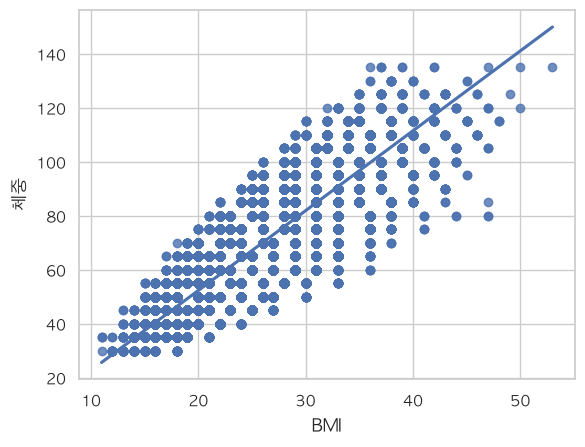

In [59]:
# 전체적인 BMI 분포를 시각화해 확인해 보세요
sns.regplot(data=health_df, x='BMI', y='체중')

<Axes: xlabel='BMI', ylabel='허리둘레'>

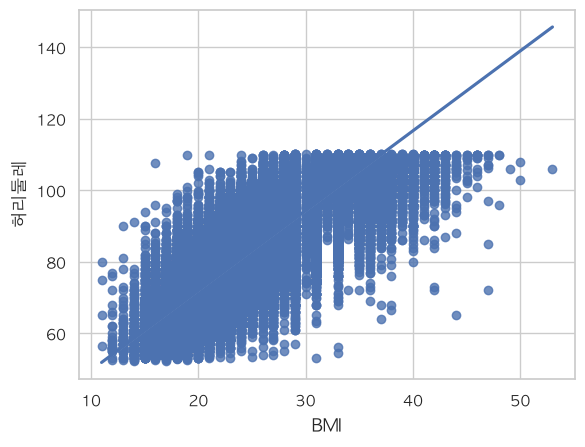

In [60]:

sns.regplot(data=health_df, x='BMI', y='허리둘레')

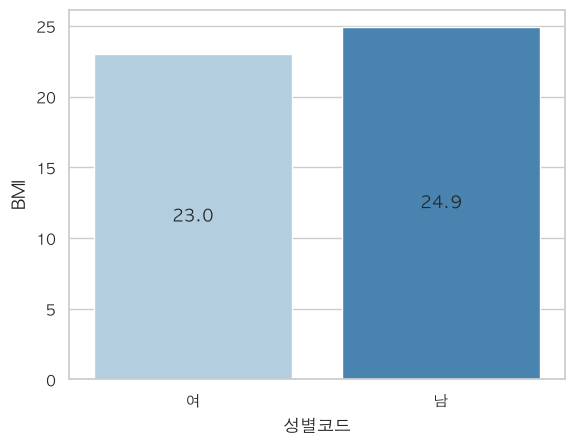

In [61]:
# BMI 분포를 성별 기준으로 구분해 살펴보세요
sns.barplot(data=health_df, x='성별코드', y='BMI', errorbar=None, palette='Blues', hue='성별코드')
show_labels()
plt.show()

### 15\. 연령대별 BMI 및 비만도 비교
연령대별로 평균 BMI이 어떻게 달라지는지 시각화해서 비교해 보세요.  
그리고 연령대별로 비만도 그룹별로 인원 비중이 어떻게 다른지도 시각화해서 확인해 보세요. (예: "20~24세" 그룹은 저체중이 20%, 정상 체중이 50%, 과체중이 20%, 비만이 10%)

In [62]:
bmi_df = health_df.groupby(['연령대코드', '비만도'], as_index=False).size()
bmi_df.head(3)

,연령대코드,비만도,size
0,20~24세,과체중,6443
1,20~24세,비만,2098
2,20~24세,저체중,4271


In [63]:
health_df.columns

Index(['가입자일련번호', '시도코드', '성별코드', '연령대코드', '신장', '체중', '허리둘레', '시력_좌', '시력_우',
       '청력_좌', '청력_우', '수축기혈압', '이완기혈압', '식전혈당', '흡연상태', '음주여부', 'BMI', '비만도'],
      dtype='str')

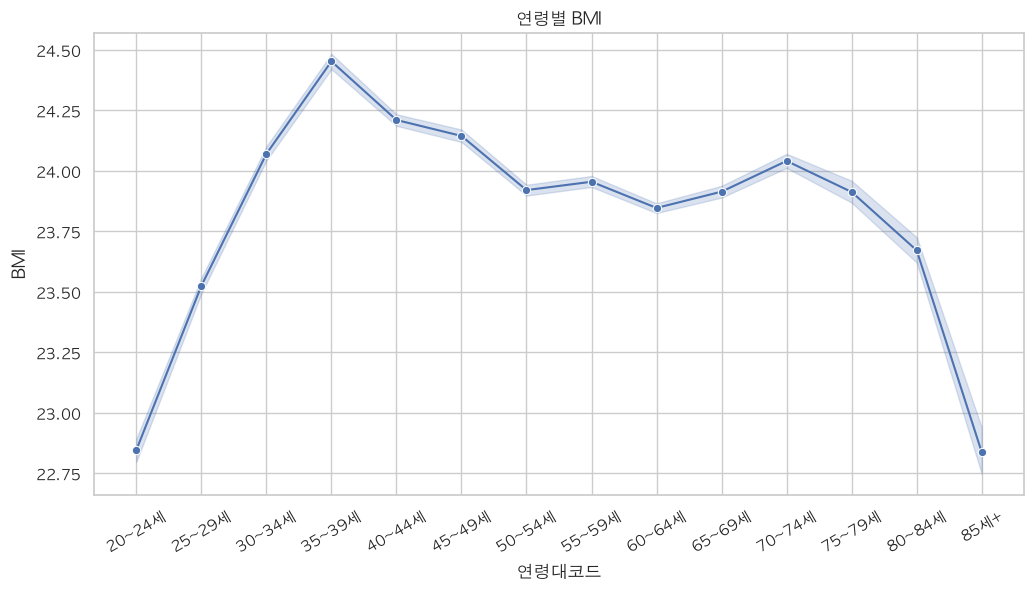

In [64]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=health_df, x='연령대코드', y='BMI', marker='o')
plt.xticks(rotation=30)
plt.title('연령별 BMI')
plt.show()

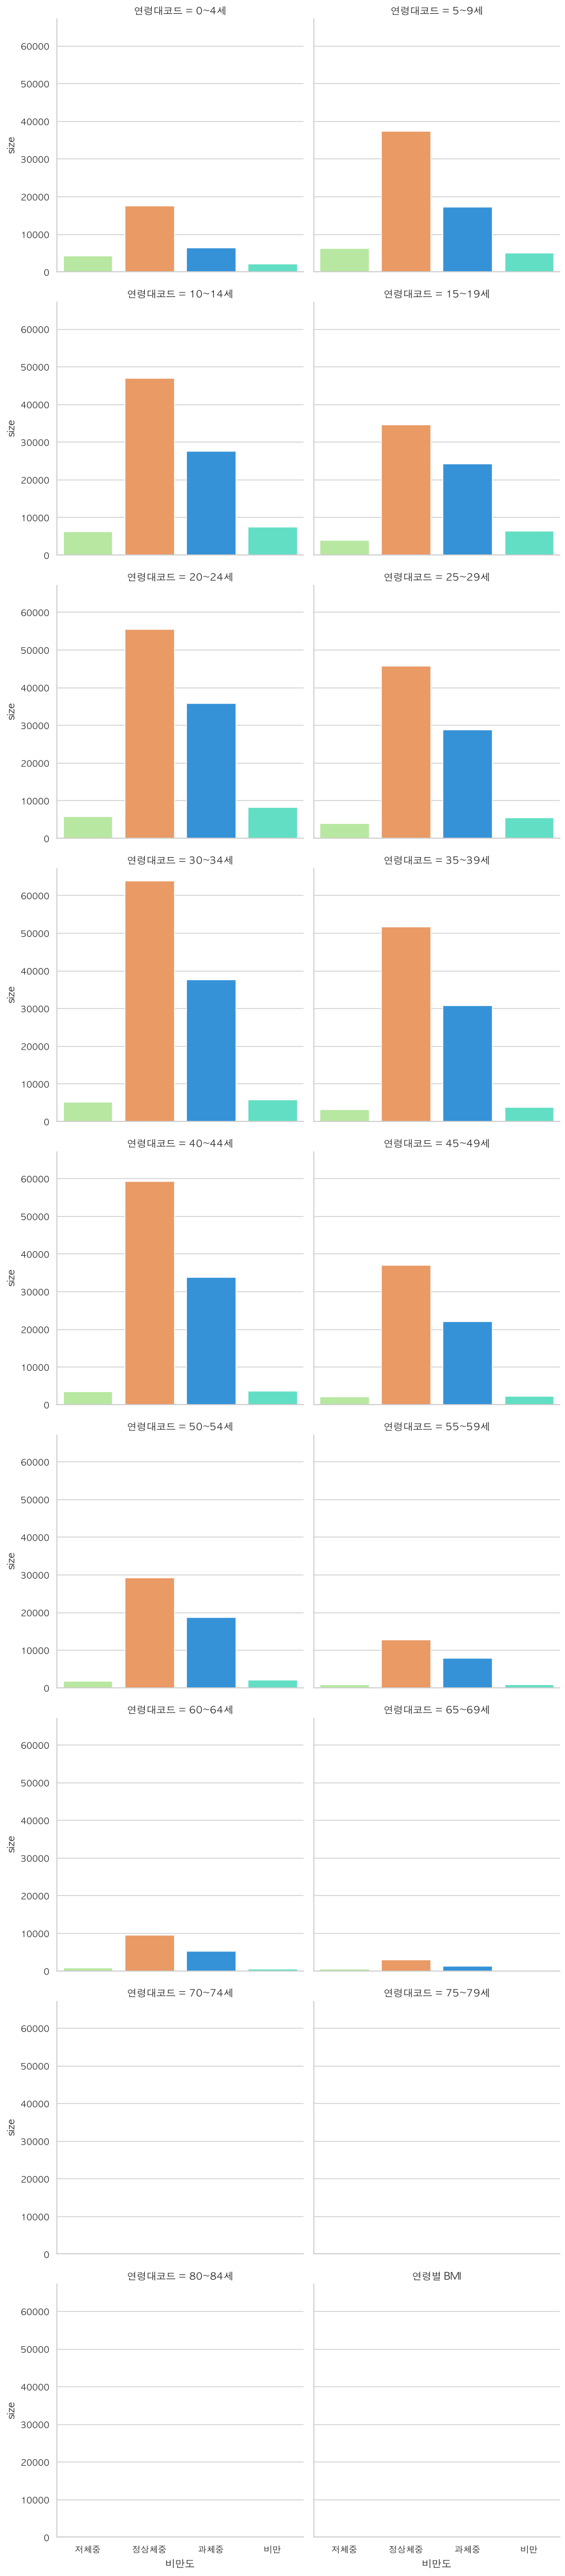

In [65]:
# 연령대별로 BMI 평균값을 비교해 보세요
fat_list = ['저체중', '정상체중', '과체중', '비만']
sns.catplot(data=bmi_df, x='비만도', y='size', col='연령대코드',col_wrap=2, hue='비만도', palette='rainbow' ,errorbar=None, kind='bar', order=fat_list)
plt.title('연령별 BMI')
plt.show()

In [66]:
# 연령대별로 비만도 그룹별 인원 비중을 비교해 보세요
total_df = bmi_df.groupby('연령대코드',as_index=False)['size'].sum()
bmi2_df = pd.merge(bmi_df, total_df, on='연령대코드' ,how='left')
bmi2_df['per'] = (bmi2_df['size_x'] / bmi2_df['size_y']) * 100
bmi2_df.head()

,연령대코드,비만도,size_x,size_y,per
0,20~24세,과체중,6443,30316,21.252804
1,20~24세,비만,2098,30316,6.920438
2,20~24세,저체중,4271,30316,14.088270
3,20~24세,정상체중,17504,30316,57.738488
4,25~29세,과체중,17305,66045,26.201832


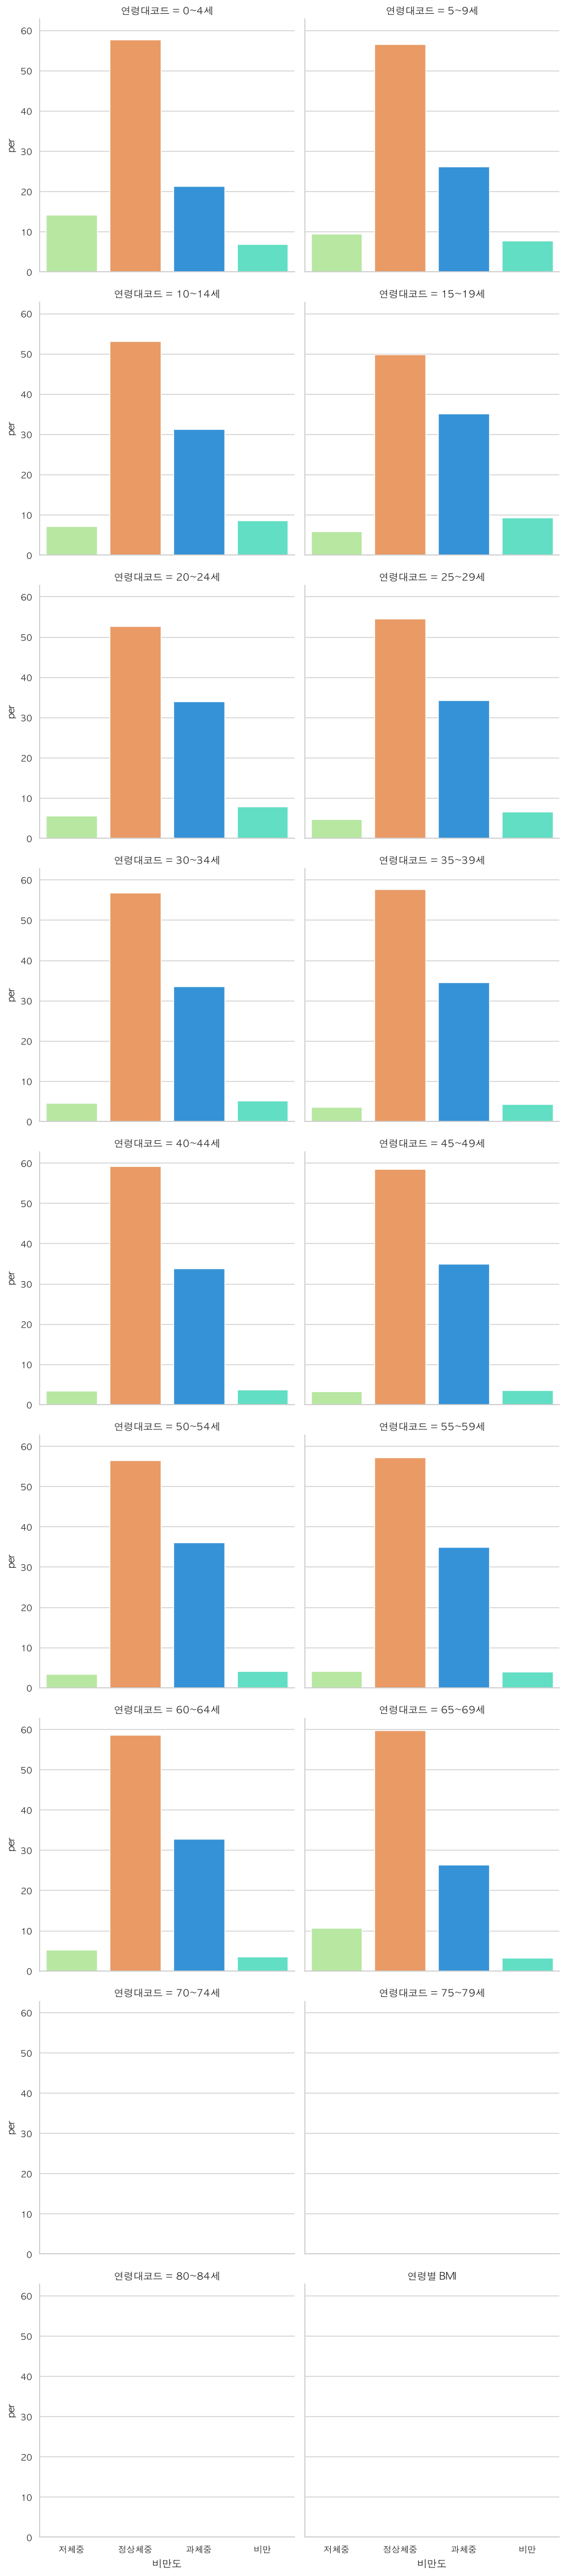

In [67]:
sns.catplot(data=bmi2_df, x='비만도', y='per', col='연령대코드',col_wrap=2, hue='비만도', palette='rainbow' ,errorbar=None, kind='bar', order=fat_list)
plt.title('연령별 BMI')
plt.show()

### 16\. BMI와 다른 건강 지표 간의 관계 분석

BMI와 다른 건강 지표(수축기혈압, 이완기혈압, 식전혈당) 간의 관계를 살펴보세요.  
먼저 산점도로 BMI와 다른 변수 간의 관계를 시각화해 확인한 후, 변수 간 상관계수를 계산하고 히트맵으로 나타내보세요.

In [68]:
health_df.columns

Index(['가입자일련번호', '시도코드', '성별코드', '연령대코드', '신장', '체중', '허리둘레', '시력_좌', '시력_우',
       '청력_좌', '청력_우', '수축기혈압', '이완기혈압', '식전혈당', '흡연상태', '음주여부', 'BMI', '비만도'],
      dtype='str')

In [69]:
# 산점도로 BMI와 다른 변수 간 관계를 시각화하세요
bmi3_df = health_df[['수축기혈압', '이완기혈압', '식전혈당', 'BMI']]
bmi3_df.describe()

,수축기혈압,이완기혈압,식전혈당,BMI
count,904323.000000,904323.000000,904323.000000,904323.000000
mean,121.612622,74.626232,96.722236,23.957003
std,13.484925,9.603998,11.662398,3.736498
min,82.000000,49.000000,64.000000,11.000000
25%,112.000000,68.000000,89.000000,21.000000
50%,120.000000,75.000000,96.000000,24.000000
75%,130.000000,81.000000,103.000000,26.000000
max,162.000000,100.000000,131.000000,53.000000


In [70]:
bmi3_df['BMI'] = bmi3_df['BMI'].astype(int)
bmi4_df = bmi3_df.groupby('BMI',as_index=False).mean()

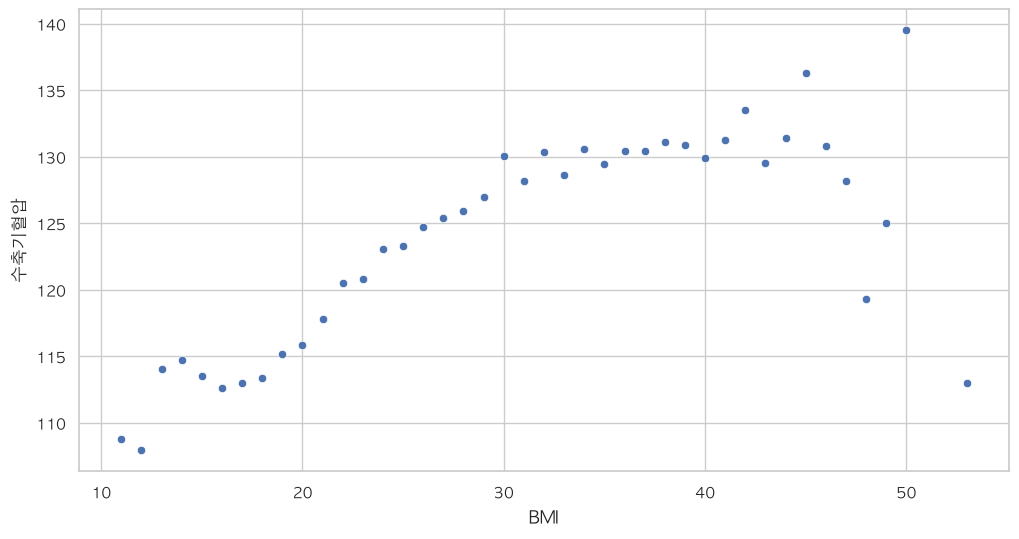

In [71]:

plt.figure(figsize=(12, 6))
sns.scatterplot(data=bmi4_df, x='BMI', y='수축기혈압')
plt.show()

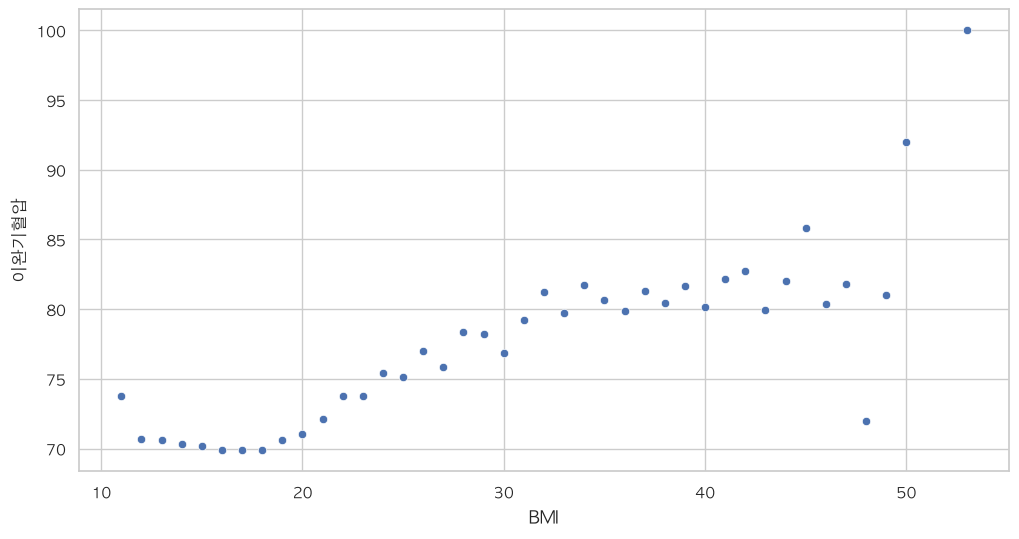

In [72]:

plt.figure(figsize=(12, 6))
sns.scatterplot(data=bmi4_df, x='BMI', y='이완기혈압')
plt.show()

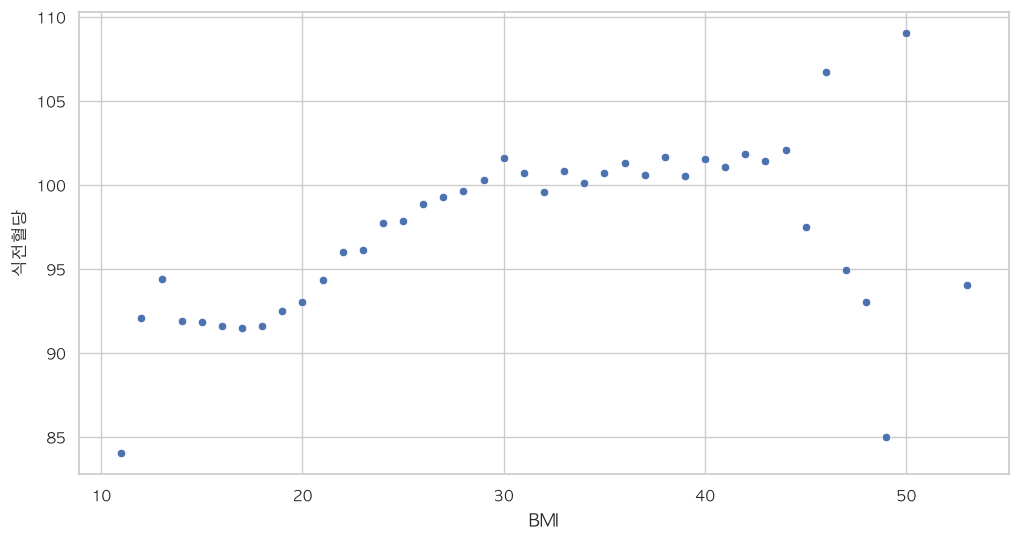

In [73]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=bmi4_df, x='BMI', y='식전혈당')
plt.show()

<Axes: >

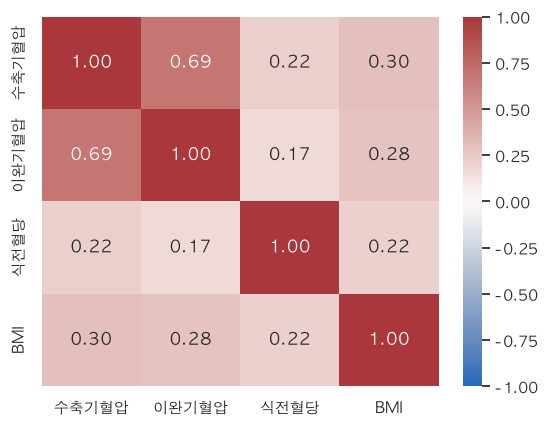

In [74]:
# 변수 간 상관계수를 계산하고 히트맵으로 나타내세요
con3 = bmi3_df.corr()
sns.heatmap(con3, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)

### 17\. 비만도 그룹별 흡연 및 음주 상태 비교
비만도 그룹별로 흡연 및 음주 상태에 차이가 있는지 비교해 보세요. 수치로만 비교하는 걸 넘어 시각화까지 해서 살펴보면 더 좋습니다.

In [75]:
# 비만도 그룹별 음주 상태를 비교해 보세요
group1_df = health_df[['수축기혈압', '이완기혈압', '식전혈당', '흡연상태', '음주여부', 'BMI', '비만도']]
con4 = group1_df.groupby(['비만도','음주여부'],as_index=False).size()
con4.head()

,비만도,음주여부,size
0,과체중,drinking,204192
1,과체중,not,93491
2,비만,drinking,38060
3,비만,not,16100
4,저체중,drinking,30262


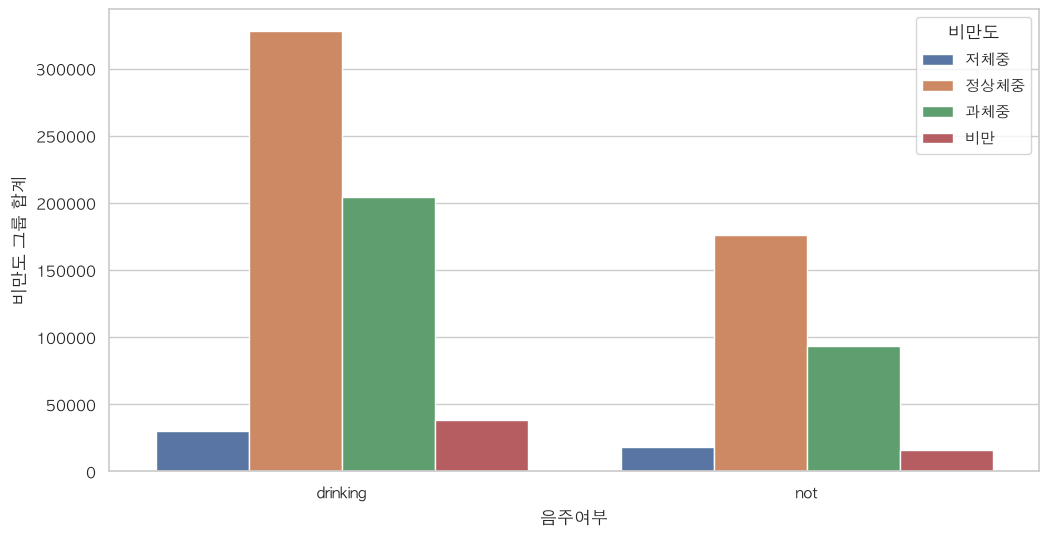

In [76]:
plt.figure(figsize=(12,6))
fat_list = ['저체중', '정상체중', '과체중', '비만']
sns.barplot(data=con4, x='음주여부', y='size', hue='비만도', hue_order=fat_list)
plt.ylabel('비만도 그룹 합계')
plt.show()


In [118]:
# 비만도 그룹별 흡연 상태를 비교해 보세요
con5 = group1_df.groupby(['비만도','흡연상태'],as_index=False).size()
con5.head()


,비만도,흡연상태,size
0,과체중,not,172010
1,과체중,smoked,65041
2,과체중,smoking,60632
3,비만,not,31787
4,비만,smoked,9802


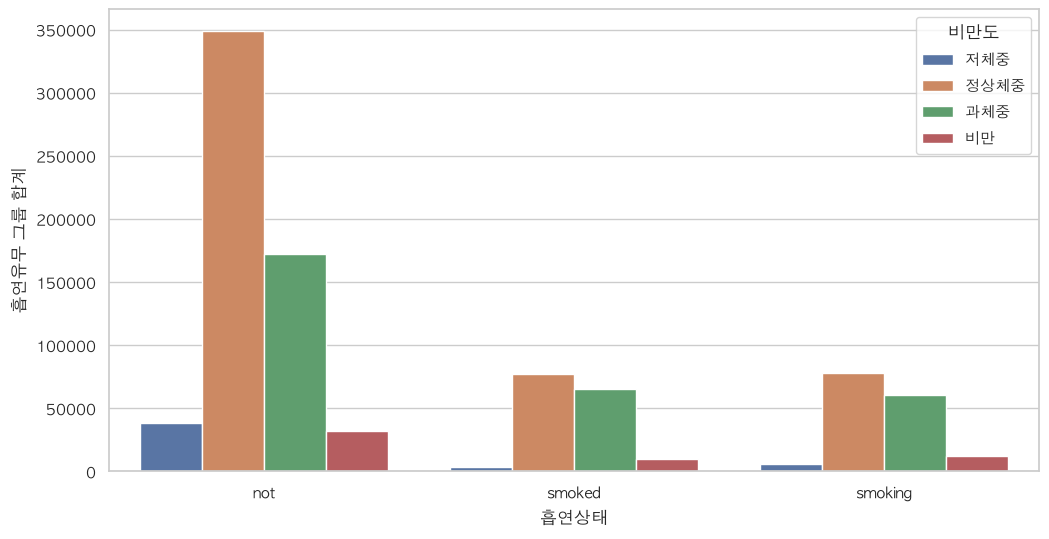

In [119]:
plt.figure(figsize=(12,6))
fat_list = ['저체중', '정상체중', '과체중', '비만']
sns.barplot(data=con5, x='흡연상태', y='size', hue='비만도', hue_order=fat_list)
plt.ylabel('흡연유무 그룹 합계')
plt.show()


In [79]:
health_df.head()

,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부,BMI,비만도
0,4831755,경기도,여,60~64세,160,50,70.0,1.0,1.0,1.0,1.0,107.0,77.0,70.0,not,drinking,20.0,정상체중
1,1154608,경기도,여,50~54세,155,60,74.9,1.0,1.0,1.0,1.0,104.0,69.0,81.0,not,drinking,25.0,과체중
2,3318236,경기도,여,60~64세,150,55,74.0,1.0,1.0,1.0,1.0,134.0,83.0,106.0,not,drinking,24.0,정상체중
3,3770599,경기도,남,75~79세,160,70,89.0,1.0,1.0,1.0,1.0,119.0,73.0,97.0,not,drinking,27.0,과체중
4,2634185,경기도,남,50~54세,175,65,76.0,1.0,1.0,1.0,1.0,103.0,64.0,115.0,not,drinking,21.0,정상체중


In [80]:
health_df.describe()

,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,BMI
count,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000,904323.000000
mean,162.747171,63.955600,80.803726,0.958405,0.956340,1.029773,1.028656,121.612622,74.626232,96.722236,23.957003
std,9.291802,13.346247,10.263722,0.545101,0.542686,0.169959,0.166837,13.484925,9.603998,11.662398,3.736498
min,130.000000,30.000000,52.300000,0.100000,0.100000,1.000000,1.000000,82.000000,49.000000,64.000000,11.000000
25%,155.000000,55.000000,73.000000,0.700000,0.700000,1.000000,1.000000,112.000000,68.000000,89.000000,21.000000
50%,165.000000,65.000000,81.000000,1.000000,1.000000,1.000000,1.000000,120.000000,75.000000,96.000000,24.000000
75%,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,81.000000,103.000000,26.000000
max,195.000000,135.000000,110.200000,9.900000,9.900000,2.000000,2.000000,162.000000,100.000000,131.000000,53.000000


---
## 심화 요구사항: 자유 EDA
주어진 데이터셋을 활용해 자유롭게 EDA(탐색적 데이터 분석)를 진행하세요.   
다양한 각도로 데이터를 관찰하다보면 데이터에 대한 이해를 높이고 생각하지 못했던 새로운 패턴을 찾아낼 수 있습니다.   
더 나아가, 발견한 내용을 알아보기 쉽게 정리하고 수치를 깔끔한 형태로 시각화하는 부분까지 신경쓰면 더욱 좋습니다.

1. 시도코드를 활용해서 지역별 나이대의 사람수와 성별을 계산해 봅니다.
2. 눈 짝짝이 시력문제 과연 노화인가?? 아니면 스마트폰 사용으로 인한 문제인가??
3. 음주와 식전혈당의 관계
4. 음주 x 흡연의 시너지 효과



In [81]:
import plotly.express as px

In [82]:
area1 = health_df.groupby(['시도코드','성별코드'],as_index=False)['가입자일련번호'].size()


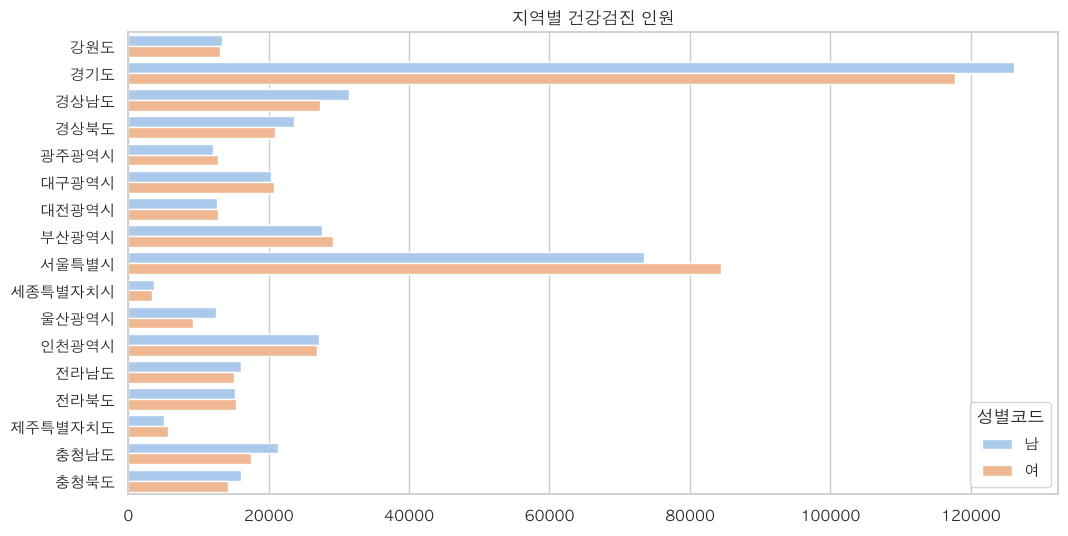

In [122]:
#1. 시도코드를 활용해서 지역별 나이대의 사람수와 성별을 계산해 봅니다.
plt.figure(figsize=(12, 6))
sns.barplot(data=area1, x='size', y='시도코드', hue='성별코드', palette='pastel')
plt.xlabel("")
plt.ylabel("")
plt.title('지역별 건강검진 인원')
plt.show()

/var/folders/r9/mb6dyn9n1qz5jbc54l10jv240000gn/T/ipykernel_2555/2840056305.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=vision_diff_by_age, x='연령대코드', y='시력차이', palette='pastel', marker='o')


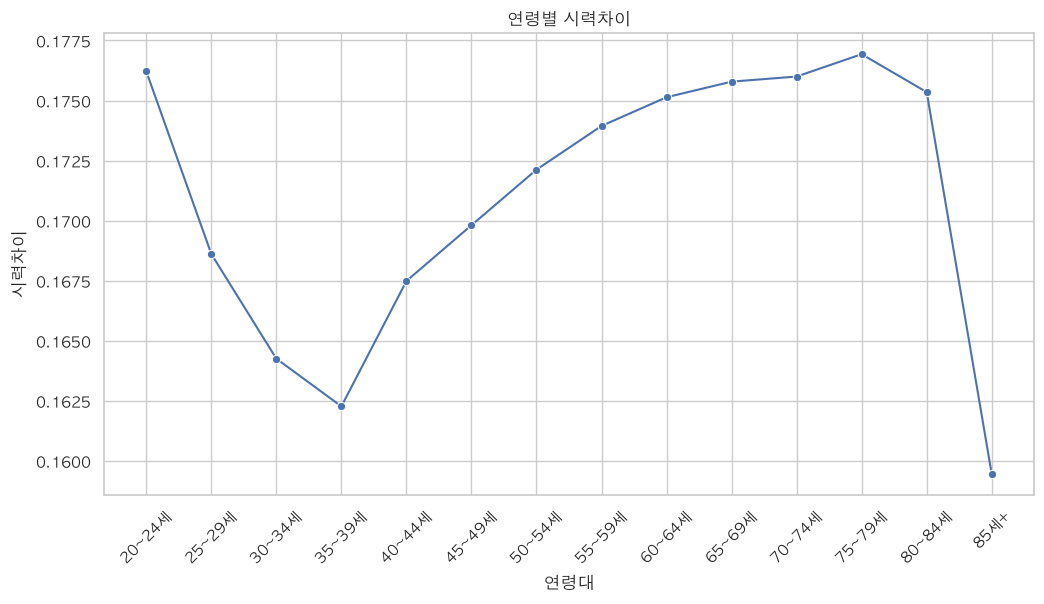

In [ ]:
v_df = health_df[(health_df['시력_좌'] <= 2.0) & (health_df['시력_우'] <= 2.0)].copy()
v_df['시력차이'] = (v_df['시력_좌'] - v_df['시력_우']).abs()
vision_diff_by_age = v_df.groupby('연령대코드', as_index=False)['시력차이'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(data=vision_diff_by_age, x='연령대코드', y='시력차이', palette='pastel', marker='o')
plt.xlabel("연령대")
plt.ylabel('시력차이')
plt.title('연령별 시력차이')
plt.xticks(rotation=45) # 어제 겹치던 글자 해결용 회전 추가
plt.show()

In [86]:
# 실명 나이때
blind_left = health_df['시력_좌'] == 9.9
blind_right = health_df['시력_우'] == 9.9
blind_df = health_df[blind_left & blind_right]
blind_df

,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부,BMI,비만도,시력차이
7633,4853100,경기도,남,45~49세,155,55,69.0,9.9,9.9,1.0,1.0,101.0,58.0,85.0,not,not,23.0,정상체중,0.0
9705,787028,경기도,남,45~49세,165,60,83.0,9.9,9.9,1.0,1.0,110.0,79.0,77.0,not,not,22.0,정상체중,0.0
10636,3481418,경기도,남,55~59세,165,50,75.0,9.9,9.9,1.0,1.0,120.0,62.0,118.0,not,drinking,18.0,저체중,0.0
36175,4904274,서울특별시,남,45~49세,180,70,79.0,9.9,9.9,1.0,1.0,123.0,84.0,94.0,not,drinking,22.0,정상체중,0.0
42961,1229184,인천광역시,여,65~69세,150,45,75.0,9.9,9.9,1.0,1.0,127.0,64.0,73.0,not,drinking,20.0,정상체중,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
982149,3321126,부산광역시,여,60~64세,145,75,102.0,9.9,9.9,1.0,1.0,117.0,65.0,97.0,not,not,36.0,비만,0.0
982236,3311748,충청남도,남,60~64세,145,45,80.0,9.9,9.9,1.0,1.0,128.0,72.0,91.0,not,not,21.0,정상체중,0.0
984327,4961712,서울특별시,남,30~34세,170,70,91.5,9.9,9.9,1.0,1.0,134.0,89.0,94.0,not,not,24.0,정상체중,0.0
985858,4361671,전라남도,여,75~79세,150,55,83.0,9.9,9.9,1.0,1.0,147.0,75.0,113.0,not,not,24.0,정상체중,0.0


In [87]:
blind1_df = blind_df['연령대코드'].value_counts().sort_index().reset_index()
blind1_df

,연령대코드,count
0,0~4세,0
1,5~9세,0
2,10~14세,0
3,15~19세,0
4,20~24세,6
5,25~29세,12
6,30~34세,14
7,35~39세,3
8,40~44세,18
9,45~49세,22


/var/folders/r9/mb6dyn9n1qz5jbc54l10jv240000gn/T/ipykernel_2555/2176131257.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=blind1_df, x='연령대코드', y='count', order=h_label, palette='rainbow')


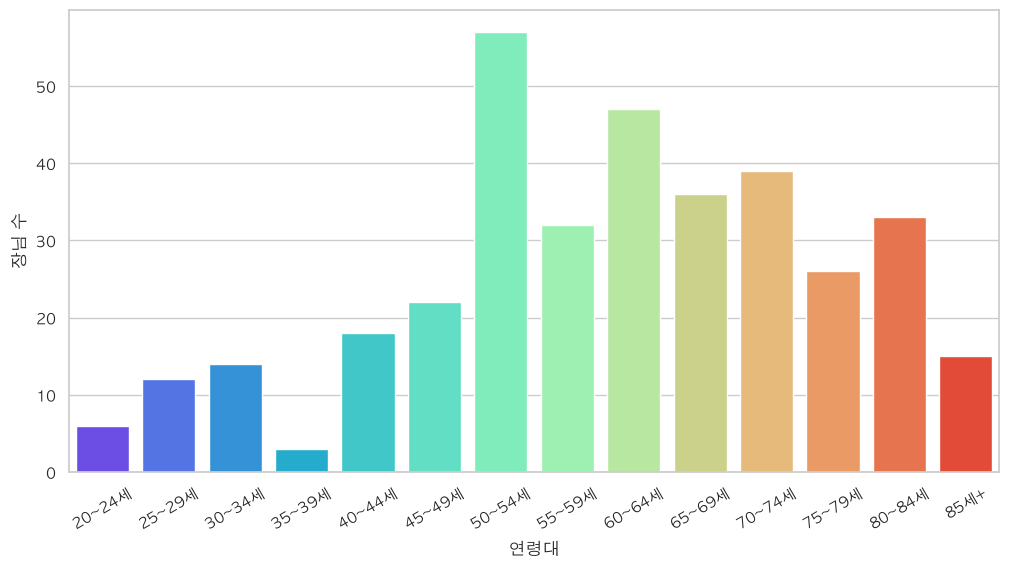

In [88]:
h_label = ['20~24세', '25~29세', '30~34세', '35~39세', '40~44세',
         '45~49세', '50~54세', '55~59세', '60~64세', '65~69세', '70~74세', '75~79세', '80~84세', '85세+']
plt.figure(figsize=(12, 6))
sns.barplot(data=blind1_df, x='연령대코드', y='count', order=h_label, palette='rainbow')
plt.xlabel('연령대')
plt.ylabel('장님 수')
plt.xticks(rotation=30)
plt.show()


In [89]:
#1. "진짜 50~60대가 당뇨/고혈압이 많은가?" (기저질환 확인)
a2_1 = blind_df.groupby('연령대코드')['식전혈당'].mean()
print(a2_1)

#2. "수검률 때문인가?" (표본 수 확인)
# 전체 데이터에서의 연령대별 인원 분포
a2_2 = health_df['연령대코드'].value_counts().sort_index()

#3. "85세 이상이 정말 실명자만 남은 것인가?" (비율 확인)

연령대코드
20~24세     84.166667
25~29세     92.916667
30~34세     95.928571
35~39세     85.000000
40~44세     94.666667
45~49세     95.454545
50~54세     95.157895
55~59세     96.656250
60~64세     96.276596
65~69세     99.805556
70~74세    100.666667
75~79세    101.615385
80~84세    101.181818
85세+       87.933333
Name: 식전혈당, dtype: float64


In [90]:
print(a2_2)

연령대코드
0~4세           0
5~9세           0
10~14세         0
15~19세         0
20~24세     30316
25~29세     66045
30~34세     88316
35~39세     69347
40~44세    105288
45~49세     83908
50~54세    112525
55~59세     89563
60~64세    100193
65~69세     63349
70~74세     51807
75~79세     22418
80~84세     16304
85세+        4944
Name: count, dtype: int64


In [91]:

total_age = health_df['연령대코드'].value_counts().sort_index()


blind_age = blind_df['연령대코드'].value_counts().sort_index()


result_1 = (blind_age / total_age) * 100


print(result_1)

연령대코드
0~4세           NaN
5~9세           NaN
10~14세         NaN
15~19세         NaN
20~24세    0.019792
25~29세    0.018169
30~34세    0.015852
35~39세    0.004326
40~44세    0.017096
45~49세    0.026219
50~54세    0.050655
55~59세    0.035729
60~64세    0.046909
65~69세    0.056828
70~74세    0.075279
75~79세    0.115978
80~84세    0.202404
85세+      0.303398
Name: count, dtype: float64


In [92]:
health_df.columns

Index(['가입자일련번호', '시도코드', '성별코드', '연령대코드', '신장', '체중', '허리둘레', '시력_좌', '시력_우',
       '청력_좌', '청력_우', '수축기혈압', '이완기혈압', '식전혈당', '흡연상태', '음주여부', 'BMI', '비만도',
       '시력차이'],
      dtype='str')

In [93]:
#3. 음주와 식전혈당의 관계
df1 = health_df.groupby('음주여부')['식전혈당'].mean().reset_index()
df1


,음주여부,식전혈당
0,drinking,96.523328
1,not,97.114777


/var/folders/r9/mb6dyn9n1qz5jbc54l10jv240000gn/T/ipykernel_2555/399732730.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=health_df, x='음주여부', y='식전혈당', palette='rainbow')


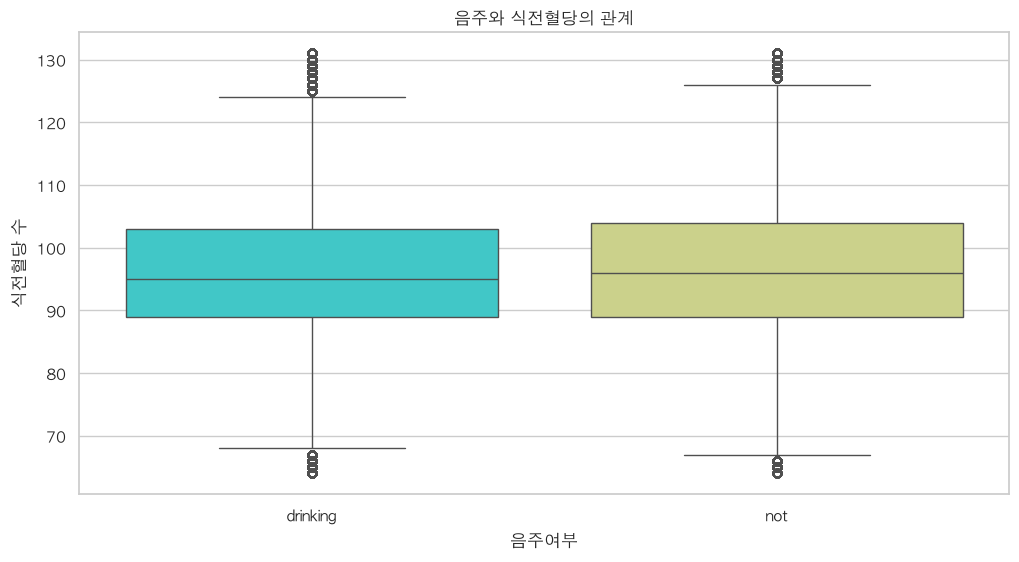

In [94]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=health_df, x='음주여부', y='식전혈당', palette='rainbow')
plt.xlabel('음주여부')
plt.ylabel('식전혈당 수')
plt.title('음주와 식전혈당의 관계')
plt.show()


In [95]:
q1 = health_df['식전혈당'].quantile(0.25)
q3 = health_df['식전혈당'].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr
high_blood_df = health_df[health_df['식전혈당'] > upper_limit]
high_blood_df['음주여부'].value_counts()

음주여부
drinking    12456
not          8104
Name: count, dtype: Int64

In [96]:
high_blood_df.groupby('연령대코드')['음주여부'].value_counts(normalize=True).reset_index()

,연령대코드,음주여부,proportion
0,20~24세,drinking,0.719298
1,20~24세,not,0.280702
2,25~29세,drinking,0.804734
3,25~29세,not,0.195266
4,30~34세,drinking,0.781977
5,30~34세,not,0.218023
6,35~39세,drinking,0.814961
7,35~39세,not,0.185039
8,40~44세,drinking,0.824726
9,40~44세,not,0.175274


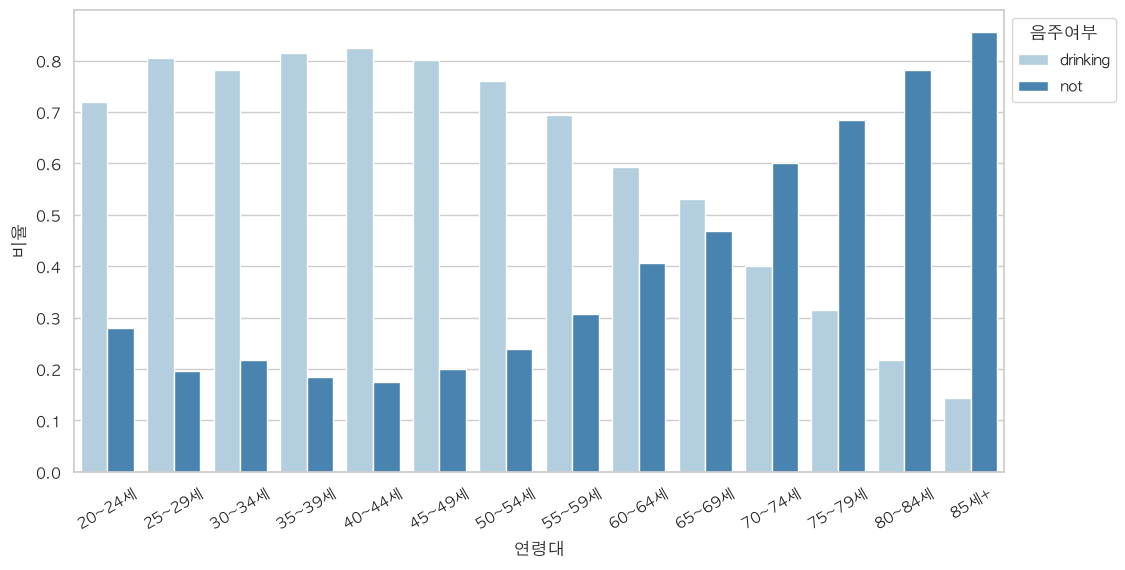

In [97]:
# 1. 고혈당군에서 연령대별 음주 여부 비율 계산
age_drink = high_blood_df.groupby('연령대코드')['음주여부'].value_counts(normalize=True).reset_index()
h_label = ['20~24세', '25~29세', '30~34세', '35~39세', '40~44세',
         '45~49세', '50~54세', '55~59세', '60~64세', '65~69세', '70~74세', '75~79세', '80~84세', '85세+']
plt.figure(figsize=(12, 6))
sns.barplot(data=age_drink, x='연령대코드',y='proportion', hue='음주여부', palette='Blues', order=h_label)
plt.legend(title='음주여부', loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('연령대')
plt.ylabel('비율')
plt.xticks(rotation=30)
plt.show()

In [98]:
#4. 음주 x 흡연의 시너지 효과
high_blood_df = health_df[health_df['식전혈당'] > upper_limit]


In [99]:
high_blood_df.groupby('흡연상태')['식전혈당'].mean()


흡연상태
not        127.762709
smoked     127.725626
smoking    127.793201
Name: 식전혈당, dtype: float64

/var/folders/r9/mb6dyn9n1qz5jbc54l10jv240000gn/T/ipykernel_2555/4246365140.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=high_blood_df, x='흡연상태', y='식전혈당', palette='rainbow')


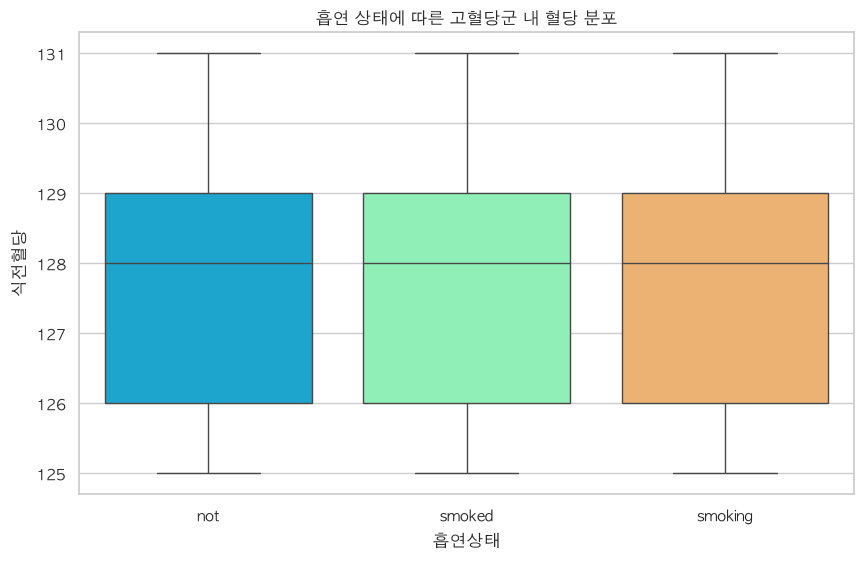

In [100]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=high_blood_df, x='흡연상태', y='식전혈당', palette='rainbow')
plt.title('흡연 상태에 따른 고혈당군 내 혈당 분포')
plt.show()

/var/folders/r9/mb6dyn9n1qz5jbc54l10jv240000gn/T/ipykernel_2555/564905449.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=health_df, x='흡연상태', y='식전혈당', palette='rainbow')


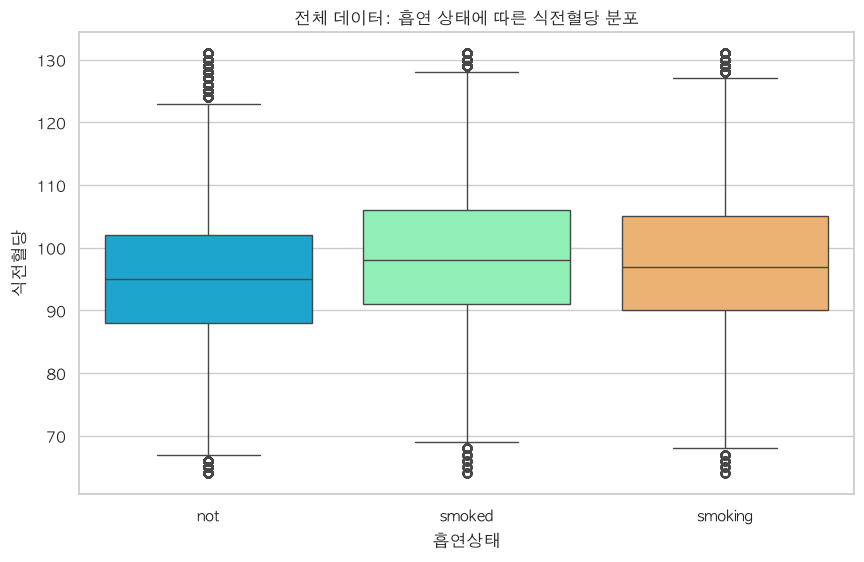

In [101]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=health_df, x='흡연상태', y='식전혈당', palette='rainbow')
plt.title('전체 데이터: 흡연 상태에 따른 식전혈당 분포')
plt.show()

In [102]:
health_df.head()

,가입자일련번호,시도코드,성별코드,연령대코드,신장,체중,허리둘레,시력_좌,시력_우,청력_좌,청력_우,수축기혈압,이완기혈압,식전혈당,흡연상태,음주여부,BMI,비만도,시력차이
0,4831755,경기도,여,60~64세,160,50,70.0,1.0,1.0,1.0,1.0,107.0,77.0,70.0,not,drinking,20.0,정상체중,0.0
1,1154608,경기도,여,50~54세,155,60,74.9,1.0,1.0,1.0,1.0,104.0,69.0,81.0,not,drinking,25.0,과체중,0.0
2,3318236,경기도,여,60~64세,150,55,74.0,1.0,1.0,1.0,1.0,134.0,83.0,106.0,not,drinking,24.0,정상체중,0.0
3,3770599,경기도,남,75~79세,160,70,89.0,1.0,1.0,1.0,1.0,119.0,73.0,97.0,not,drinking,27.0,과체중,0.0
4,2634185,경기도,남,50~54세,175,65,76.0,1.0,1.0,1.0,1.0,103.0,64.0,115.0,not,drinking,21.0,정상체중,0.0


In [103]:
health_df.to_csv("health_checkup_2024_clean.csv", index=False, encoding="utf-8-sig")

In [115]:
plt.tight_layout()
plt.savefig(
    "지역별_성별_검진인원.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

In [117]:
health_df.shape

(870716, 19)

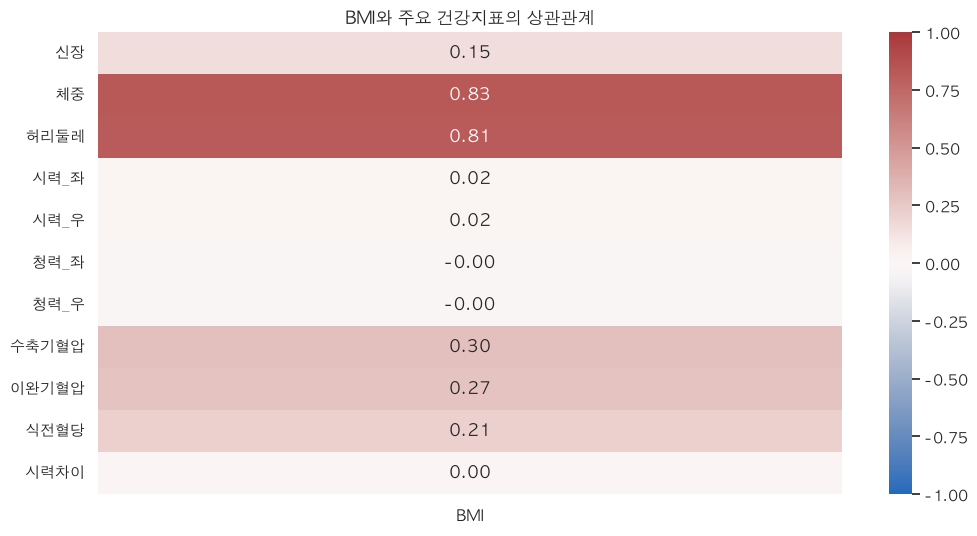

In [127]:
plt.figure(figsize=(12,6))
con1 = health_df.corr(numeric_only=True)[['BMI']].drop('BMI', axis=0)
sns.heatmap(con1, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('BMI와 주요 건강지표의 상관관계')
plt.show()